# compare ETCCDI indices from CanEsm
Here we test the homemade ETCCDI index functions

# Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

# ---
# logging setup
# ---
import logging
from pathlib import Path

from pyClimExtremes.logging.setup_logging import (
    configure_package_logger as configure_pyclimextremes_logger,
)

configure_pyclimextremes_logger(
    level=logging.DEBUG,
    propagate=True,
    add_handler=True,
    fmt='%(name)s - %(levelname)s - %(message)s'
)

from pyClimExtremes.indices import get_creatable_indices
from pyClimExtremes.scripts.compute_indices import compute_indices

# ---
# imports
# ---

system = 'fruh'  # Change this to 'nird' or 'ipcc' as needed
if system == 'fruh':
    raw_data_path = Path('/home/johannlf/Downloads/raw_input')
    refdir_path = Path('/home/johannlf/Downloads/ETCCDI_output')
    savepath = Path('/home/johannlf/Downloads/homemade_output')
elif system == 'victor':
    raw_data_path = Path('/scratch/johannlf/')
    refdir_path = Path('/scratch/johannlf/ETCCDI_output')
    savepath = Path('/scratch/johannlf/homemade_output')
elif system == 'nird' or system == 'ipcc':
    raw_data_path = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/raw_input')
    refdir_path = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/ETCCDI_output')
    savepath = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/homemade_output')
else:
    raise ValueError(f"Unknown system: {system}")

pyClimExtremes.indices.registry - DEBUG - Registered impact index 'fdETCCDI' of type 'temperature' with ID 'fdETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'suETCCDI' of type 'temperature' with ID 'suETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'idETCCDI' of type 'temperature' with ID 'idETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'trETCCDI' of type 'temperature' with ID 'trETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'txxETCCDI' of type 'temperature' with ID 'txxETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'txnETCCDI' of type 'temperature' with ID 'txnETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'tnxETCCDI' of type 'temperature' with ID 'tnxETCCDI'.
pyClimExtremes.indices.registry - DEBUG - Registered impact index 'tnnETCCDI' of type 'temperature' with ID 'tnnETCCDI'.
pyClimExtremes.indices.registry - DEBUG 

# Reference data

In [2]:
input_files = list(raw_data_path.glob('*CanESM5*.nc'))
for file in input_files:
    print(file.name)

pr_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc
tasmax_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_ssp585_r1i1p1f1_gn_21010101-21801231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tasmin_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tasmax_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21801231.nc
tas_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc


In [3]:
run_process = False
if not run_process:
    print("Skipping unit conversion process.")
else:
    def convert_K_to_C(ds):
        for data_var in [var for var in ds.data_vars if 'tas' in var]:
            if ds[data_var].units == 'K':
                ds[data_var] = ds[data_var] - 273.15
                ds[data_var].attrs['units'] = 'deg_C'
        return ds

    def convert_pr_units(ds):
        for data_var in [var for var in ds.data_vars if 'pr' in var]:
            if ds[data_var].units == 'kg m-2 s-1':
                ds[data_var] = ds[data_var] * 86400  # Convert to mm/day
                ds[data_var].attrs['units'] = 'mm/day'
        return ds

    fixed_input_path = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/fixed_input')
    if not fixed_input_path.exists():
        fixed_input_path.mkdir(parents=True, exist_ok=True)

    for indx, file in enumerate(input_files):
        ds = xr.open_dataset(file)
        if not any(ds[var].units == 'K' for var in ds.data_vars if 'tas' in var):
            print(f'{file.name}: No K to C conversion needed.')
            ds.close()
            continue  # No conversion needed
        ds_converted = convert_K_to_C(ds)
        new_path = fixed_input_path / file.name
        ds_converted.to_netcdf(new_path)
        ds.close()
        ds_converted.close()
        print(f'{file.name}: Converted K to C and saved to {new_path}')

        input_files[indx] = new_path  # Update the list to point to the fixed files
    for indx, file in enumerate(input_files):
        ds = xr.open_dataset(file)
        if not any(ds[var].units == 'kg m-2 s-1' for var in ds.data_vars if 'pr' in var):
            print(f'{file.name}: No pr unit conversion needed.')
            ds.close()
            continue  # No conversion needed
        ds_converted = convert_pr_units(ds)
        new_path = fixed_input_path / file.name
        ds_converted.to_netcdf(new_path)
        ds.close()
        ds_converted.close()
        print(f'{file.name}: Converted pr units and saved to {new_path}')

        input_files[indx] = new_path  # Update the list to point to the fixed files

Skipping unit conversion process.


# Controlcalculation

## Temperature

In [4]:
index_ids = list(get_creatable_indices(subset="temperature", print_msg=True).keys())

Available creatable temperature indices:
 - fdETCCDI: Frost days,
 - suETCCDI: Summer days,
 - idETCCDI: Ice days,
 - trETCCDI: Tropical nights,
 - txxETCCDI: Maximum of daily maximum temperature,
 - txnETCCDI: Minimum of daily maximum temperature,
 - tnxETCCDI: Maximum of daily minimum temperature,
 - tnnETCCDI: Minimum of daily minimum temperature,
 - dtrETCCDI: Daily temperature range,
 - tn10pETCCDI: Percentage of days when daily minimum temperature < 10th percentile of daily minimum temperature during the baseline period,
 - tn90pETCCDI: Percentage of days when daily minimum temperature > 90th percentile of daily minimum temperature during the baseline period,
 - tx10pETCCDI: Percentage of days when daily maximum temperature < 10th percentile of daily maximum temperature during the baseline period,
 - tx90pETCCDI: Percentage of days when daily maximum temperature > 90th percentile of daily maximum temperature during the baseline period,
 - wsdiETCCDI: Warm spell duration index,
 -

In [5]:
kwargs = {
    'threshold': {
        'su': [25+273.15, 30+273.15],  # Summer days threshold in K
    },
    'baseline_period': (1981, 2010),
}
new_files, skipped_files = compute_indices(
    indices=[
        'fdETCCDI', 'suETCCDI', 'idETCCDI',
        'trETCCDI', 'txxETCCDI',
        'txnETCCDI', 'tnxETCCDI', 'tnnETCCDI',
        'dtrETCCDI',
        # Quantile-threshold indices (thresholds computed in-memory from baseline)
        'tn10pETCCDI', 'tn90pETCCDI', 'tx10pETCCDI', 'tx90pETCCDI',
        'wsdiETCCDI', 'csdiETCCDI',
    ],
    compute_fq=['yr'],
    compute_backend='python',
    output_dir=savepath,
    output_file_template="cmip6",
    tasmax=Path(raw_data_path / 'tasmax_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    tasmin=Path(raw_data_path / 'tasmin_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    tas=Path(raw_data_path / 'tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    pr=None,
    overwrite=True,
    **kwargs
)


pyClimExtremes.indices.registry - DEBUG - Resolved indices to compute: [<class 'pyClimExtremes.indices.temperature_indices.FDINDEX'>, <class 'pyClimExtremes.indices.temperature_indices.SUINDEX'>, <class 'pyClimExtremes.indices.temperature_indices.IDINDEX'>, <class 'pyClimExtremes.indices.temperature_indices.TRINDEX'>, <class 'pyClimExtremes.indices.temperature_indices.TXxIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TXnIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TNxIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TNnIndex'>, <class 'pyClimExtremes.indices.temperature_indices.DTRIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TN10pIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TN90pIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TX10pIndex'>, <class 'pyClimExtremes.indices.temperature_indices.TX90pIndex'>, <class 'pyClimExtremes.indices.temperature_indices.WSDIIndex'>, <class 'pyClimExtremes.indices.temperatur

pyClimExtremes.scripts.compute_indices - INFO - Computing index 'suETCCDI' at frequency 'yr'. Data units: 'K' and threshold = 298.15.
pyClimExtremes.indices.base_index - DEBUG - Unfiltered kwargs keys: ['compute_fq', 'group_index', 'threshold', 'threshold_array', 'tasmax_data', 'time_array', 'time_units', 'calendar', 'lat']
pyClimExtremes.indices.base_index - DEBUG - Unwrapped method signature parameters: ['self', 'compute_fq', 'tasmax_data', 'group_index', 'threshold']
pyClimExtremes.indices.base_index - DEBUG - Calling su with kwargs: ['compute_fq', 'group_index', 'threshold', 'tasmax_data']
pyClimExtremes.compute_backend.python_backend - DEBUG - Computed SU with threshold=298.15 and shape (165, 64, 128)
pyClimExtremes.io.netcdf_write - DEBUG - Adding 'source_id': 'CanESM5' to filename
pyClimExtremes.io.netcdf_write - DEBUG - Adding 'experiment_id': 'historical' to filename
pyClimExtremes.io.netcdf_write - DEBUG - Adding 'variant_label': 'r1i1p1f1' to filename
pyClimExtremes.io.netcd

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Skipping fdETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 0

Checking for fdETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


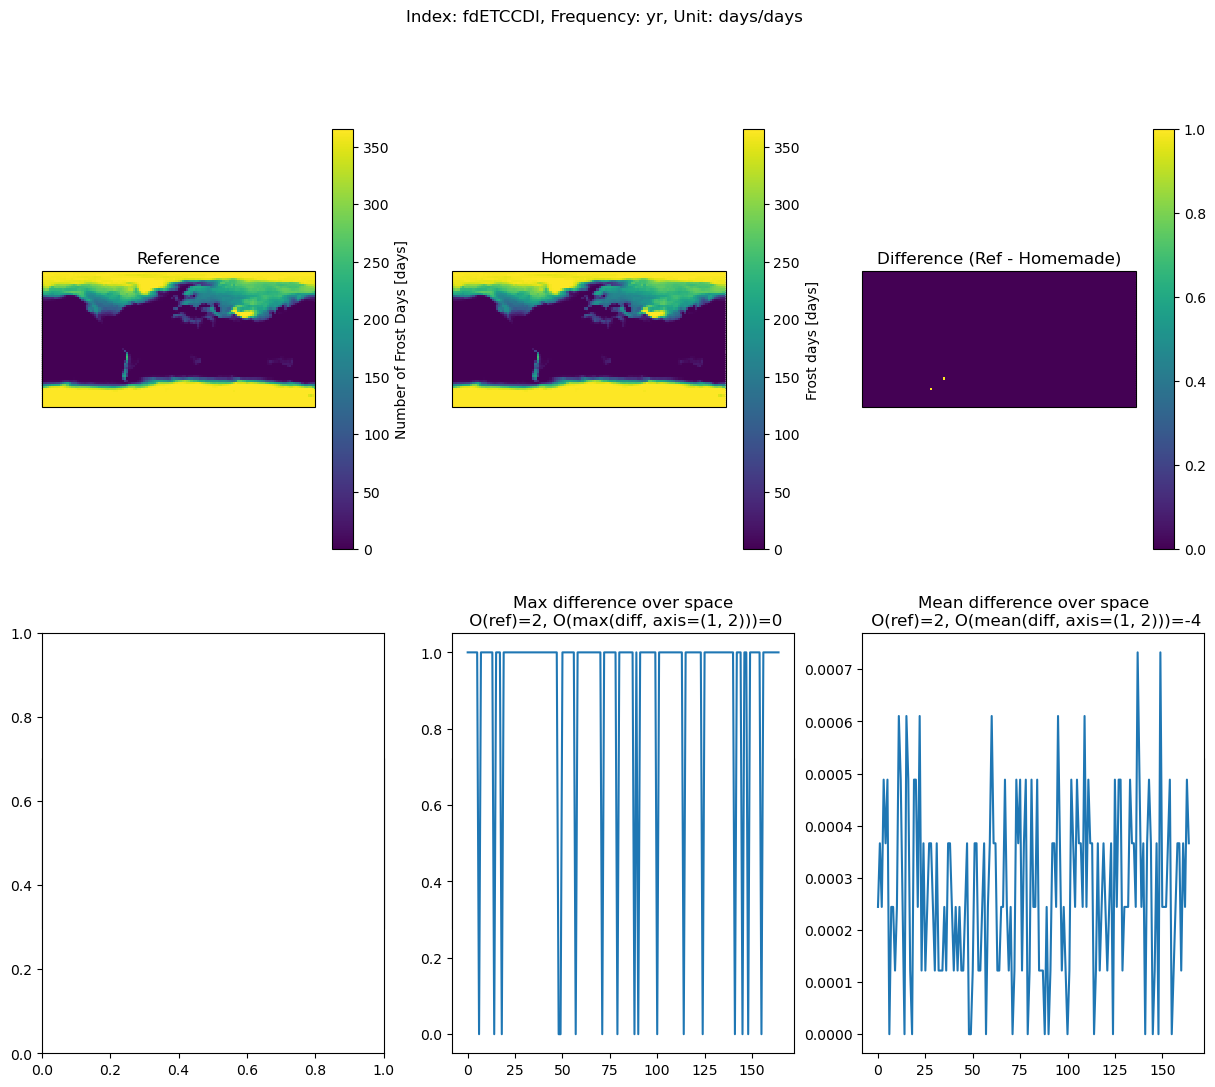


Skipping suETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 0

Skipping suETCCDI at yr due to unexpected number of files. Homemade: 2, ref: 1

Skipping idETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 0

Checking for idETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


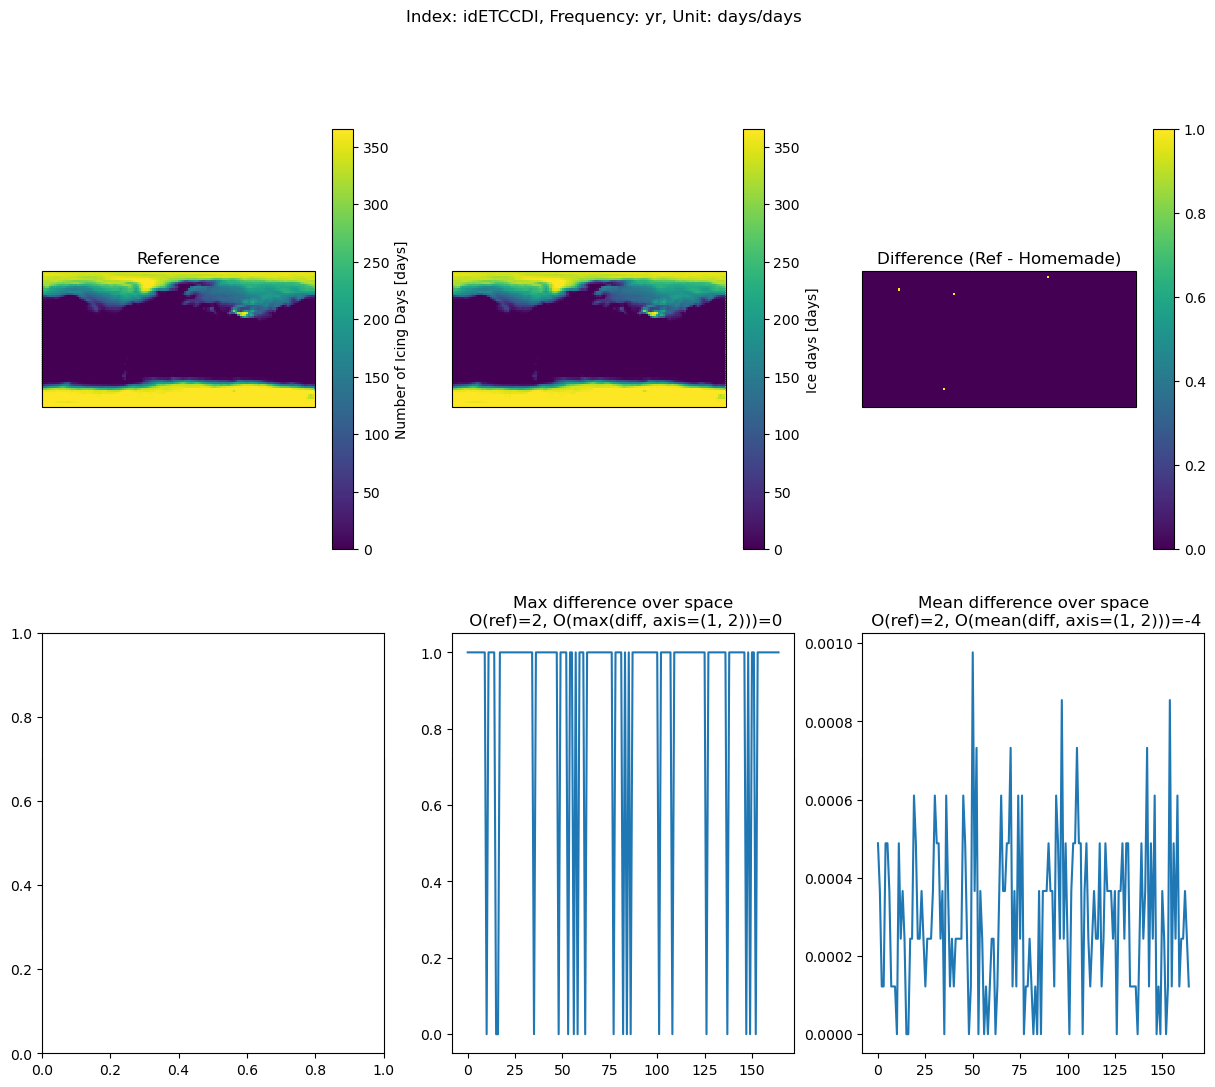


Skipping trETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 0

Skipping trETCCDI at yr due to unexpected number of files. Homemade: 2, ref: 1

Skipping txxETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for txxETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


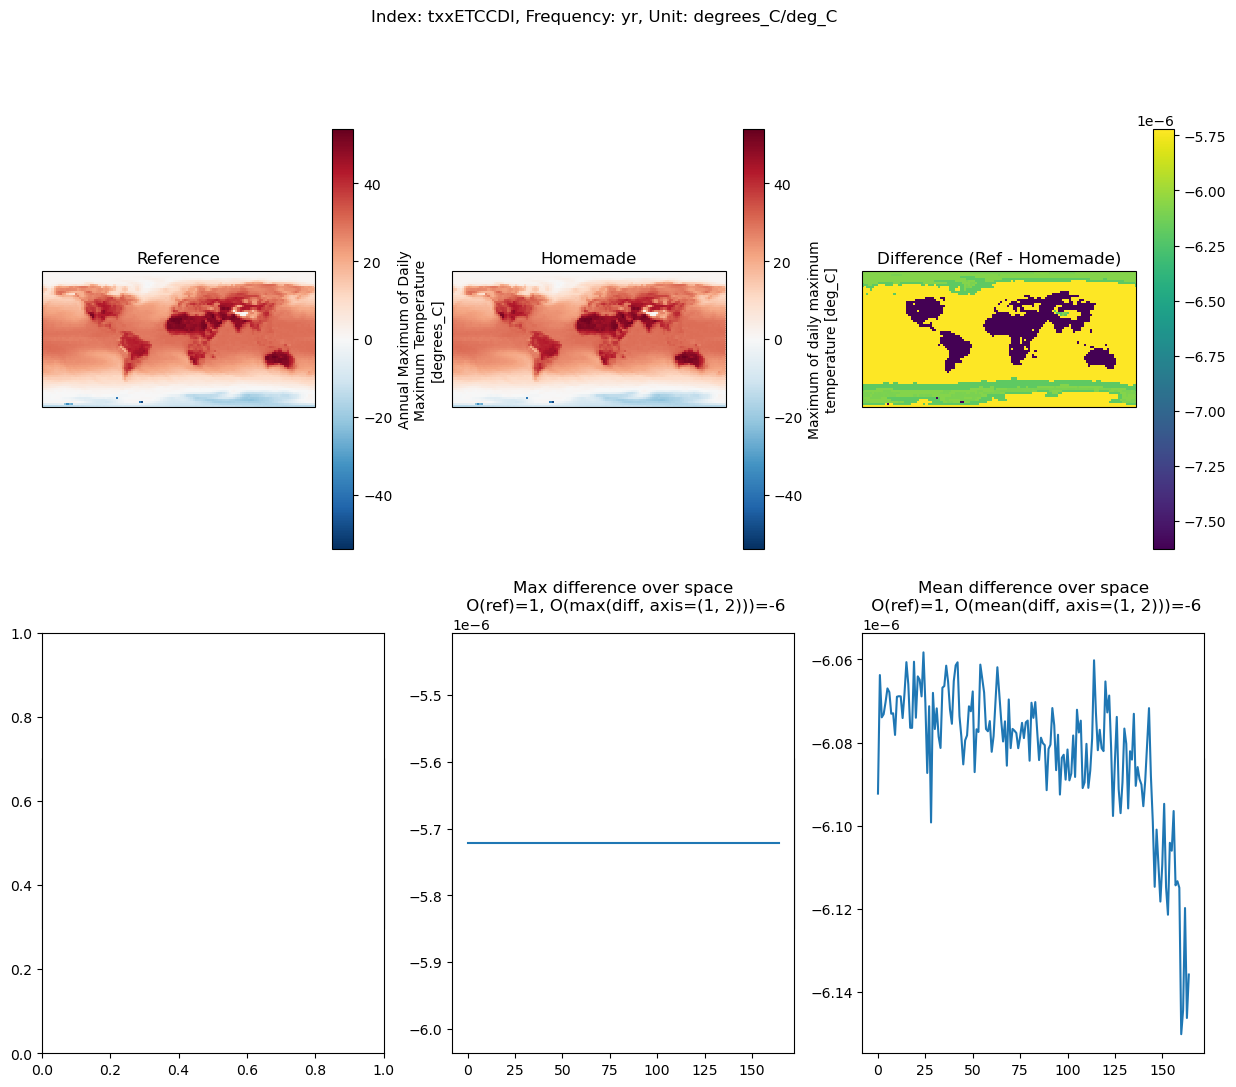


Skipping txnETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for txnETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


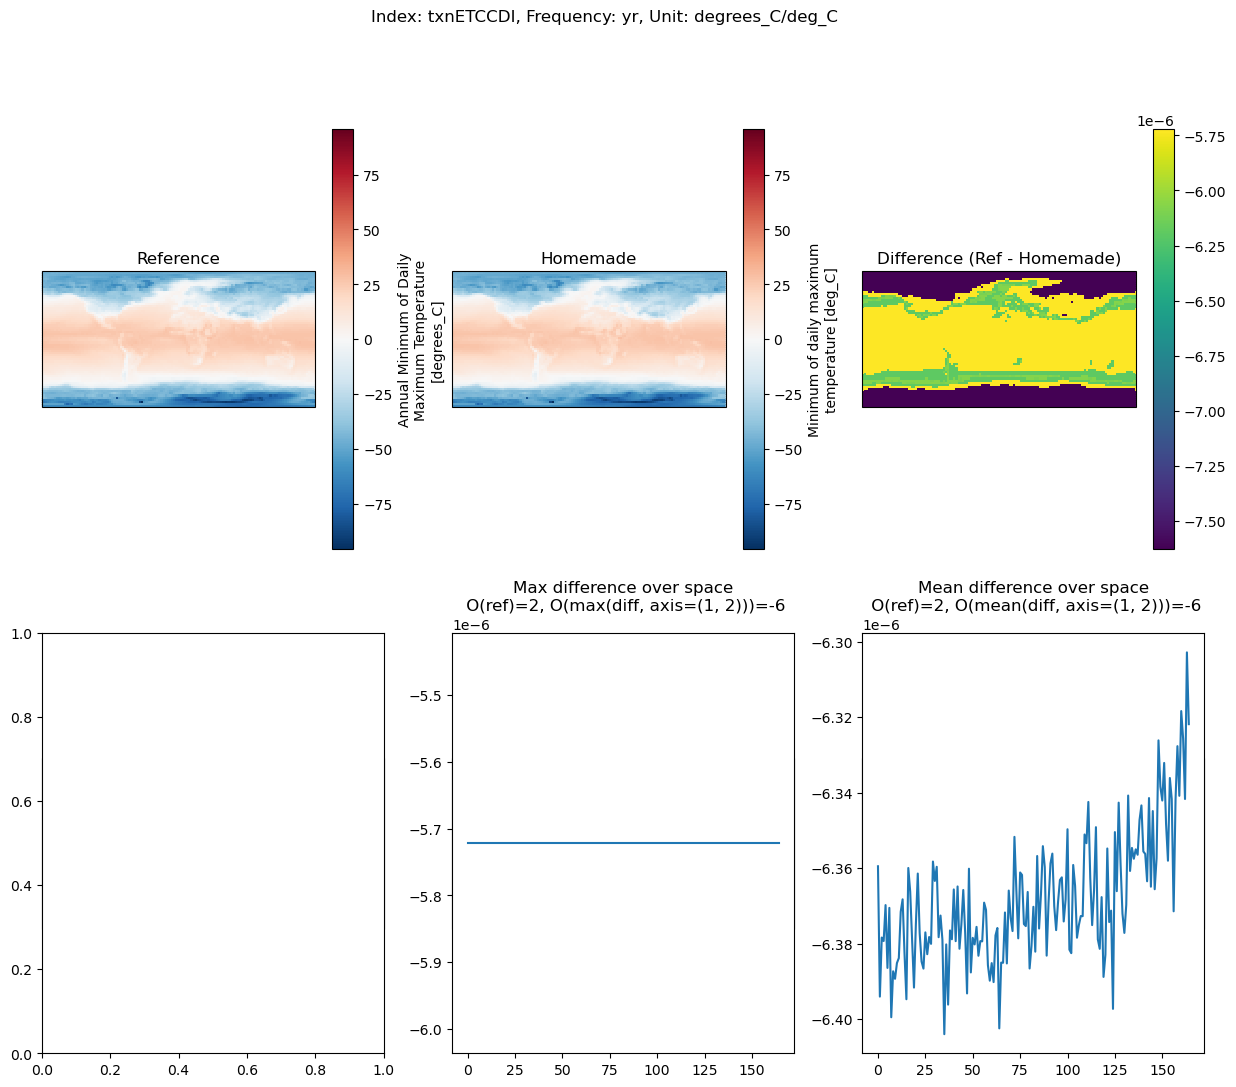


Skipping tnxETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for tnxETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


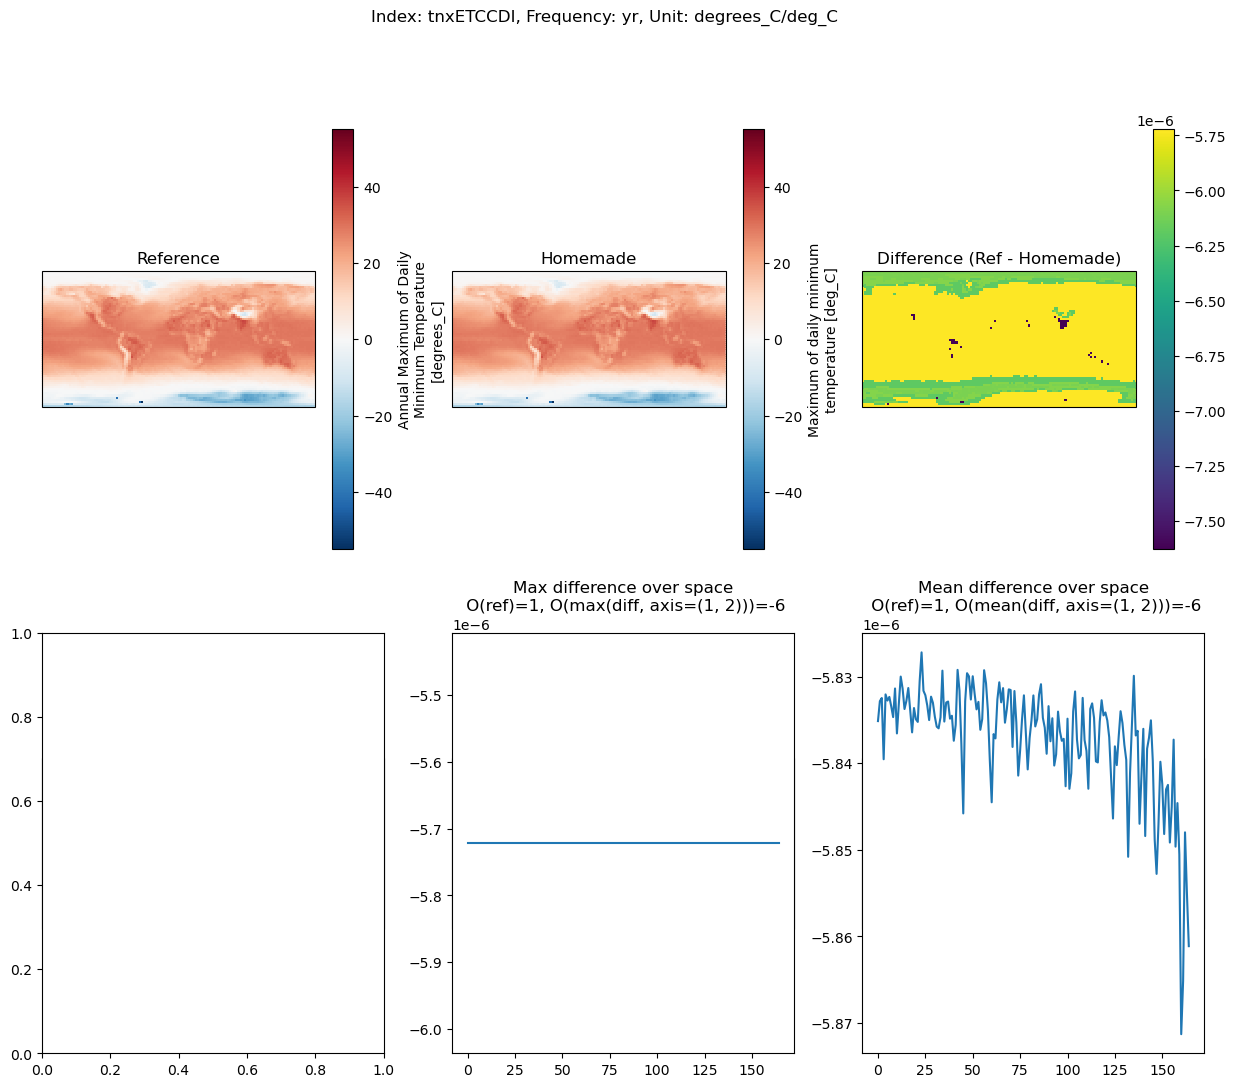


Skipping tnnETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for tnnETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


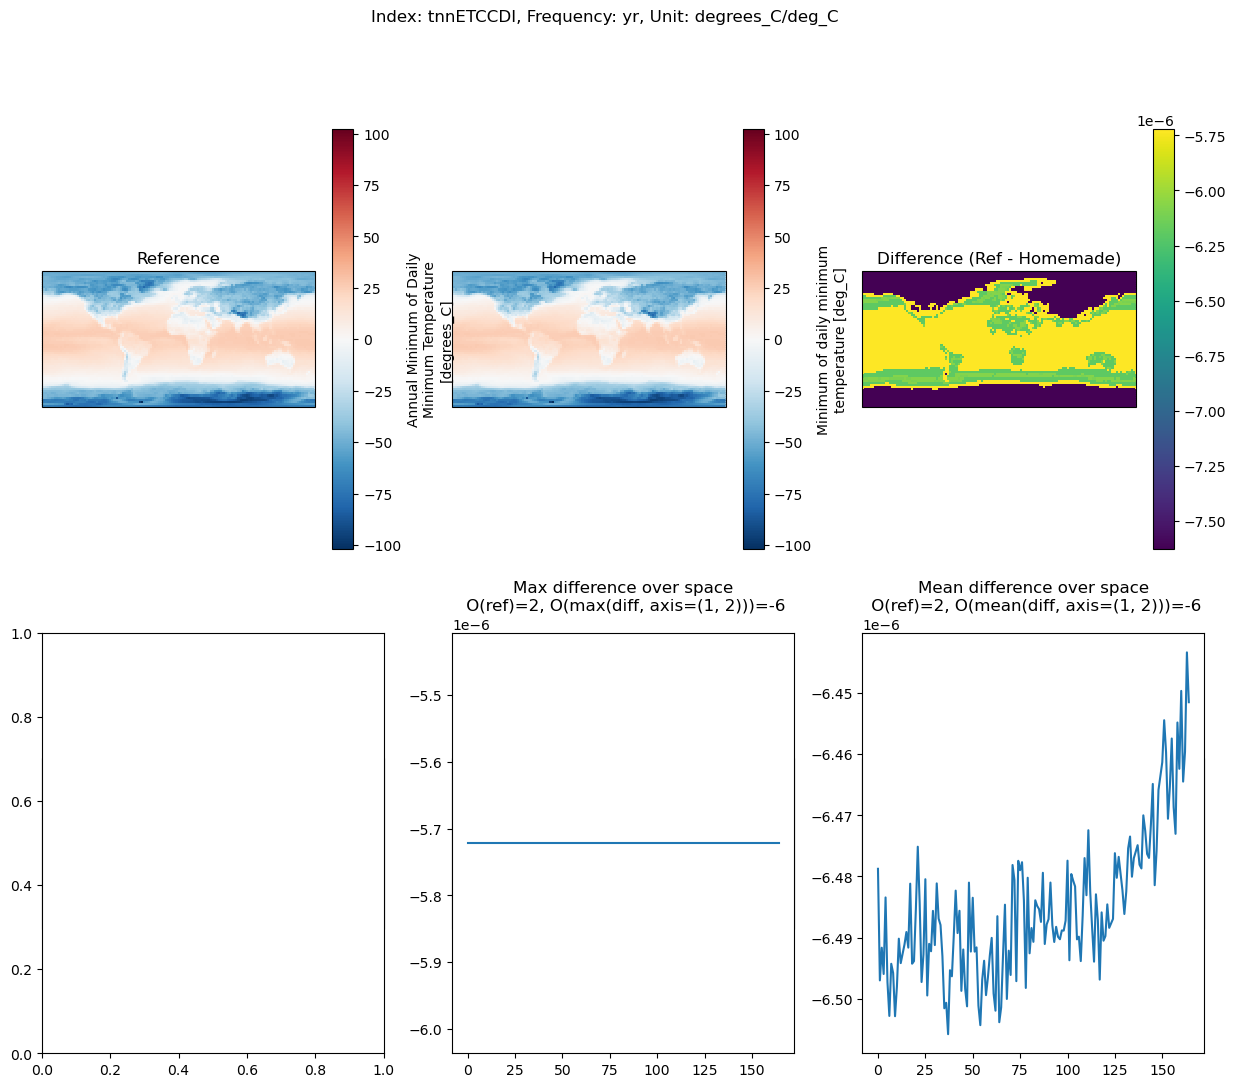


Skipping dtrETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for dtrETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


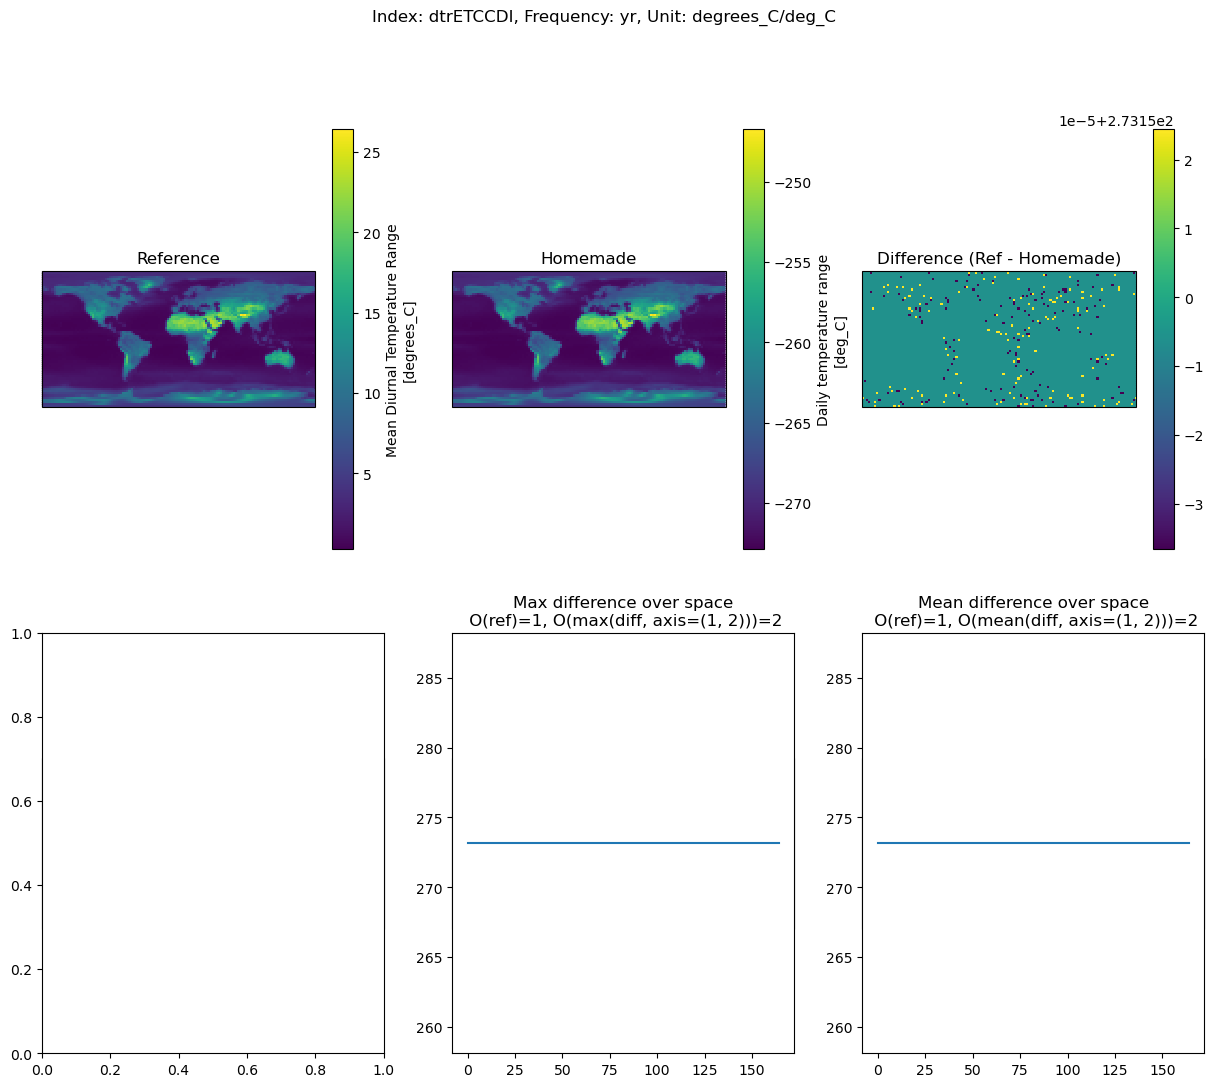


Skipping tn10pETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for tn10pETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


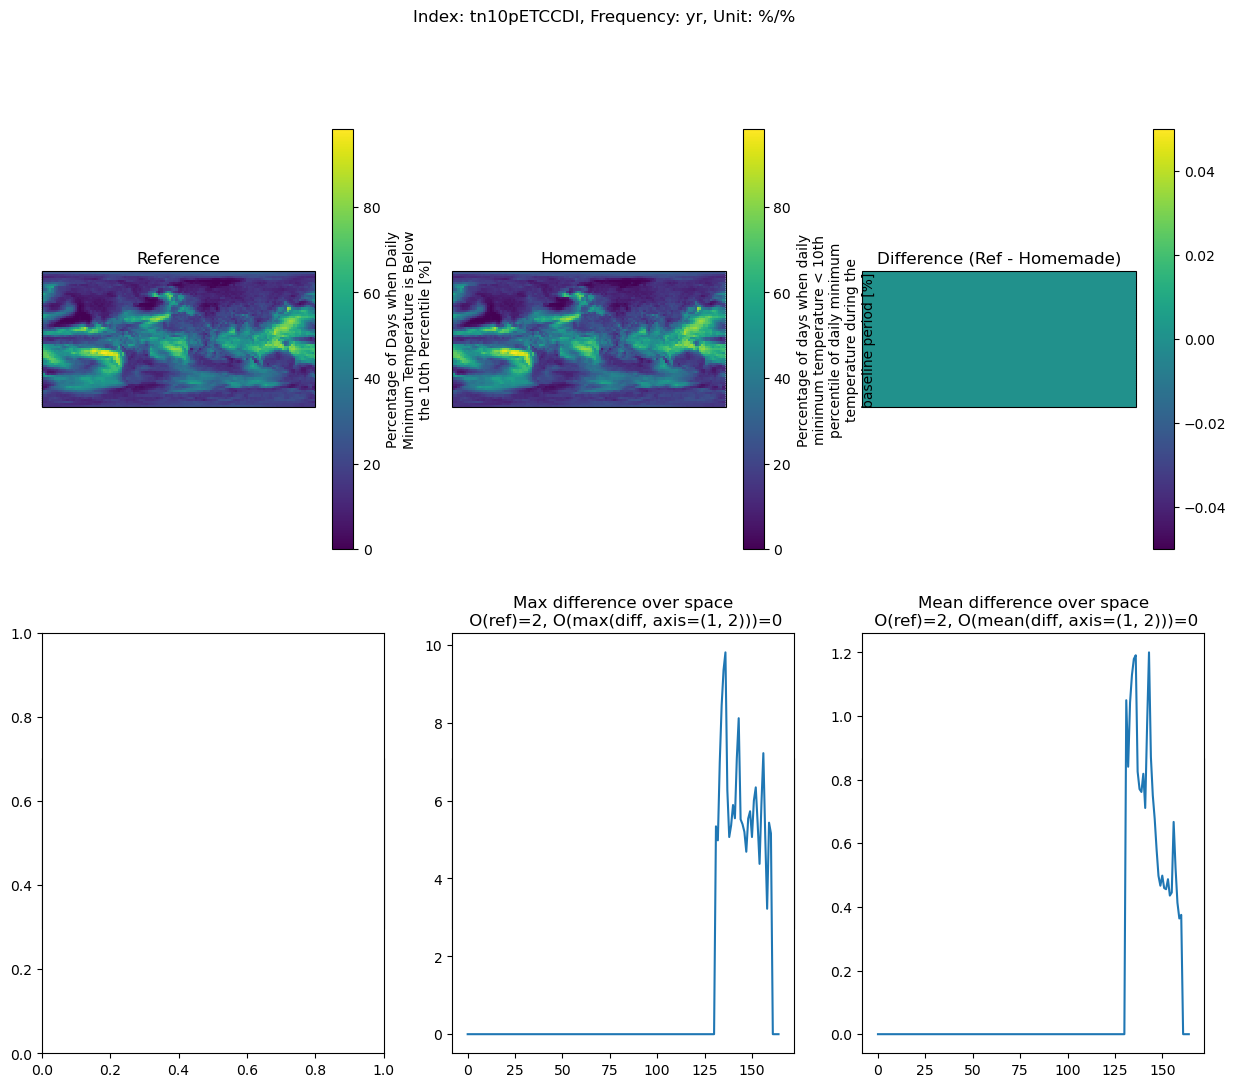


Skipping tn90pETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for tn90pETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


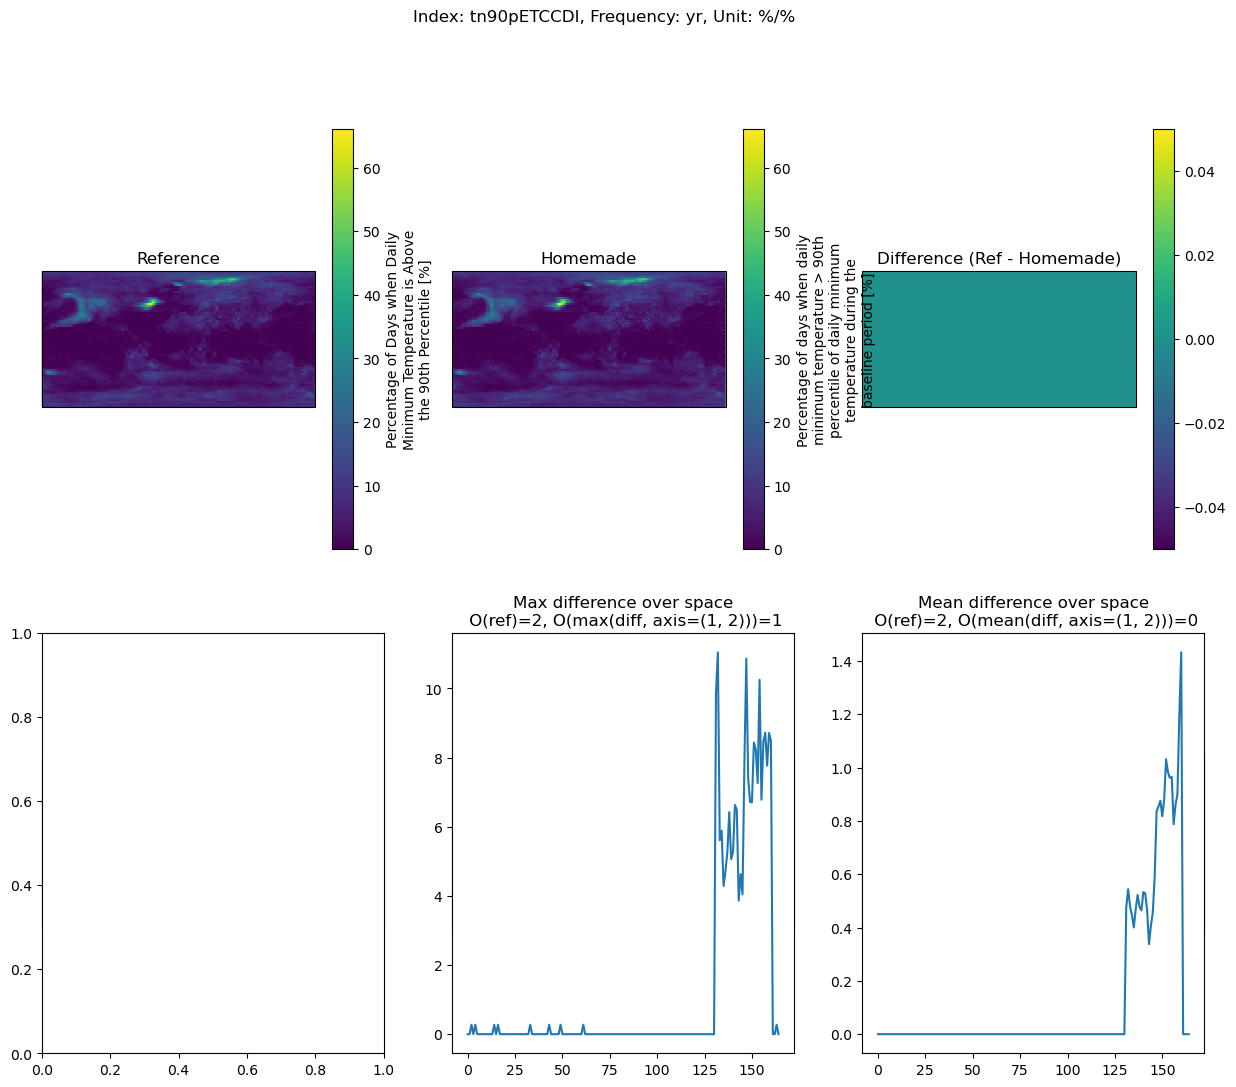


Skipping tx10pETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for tx10pETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


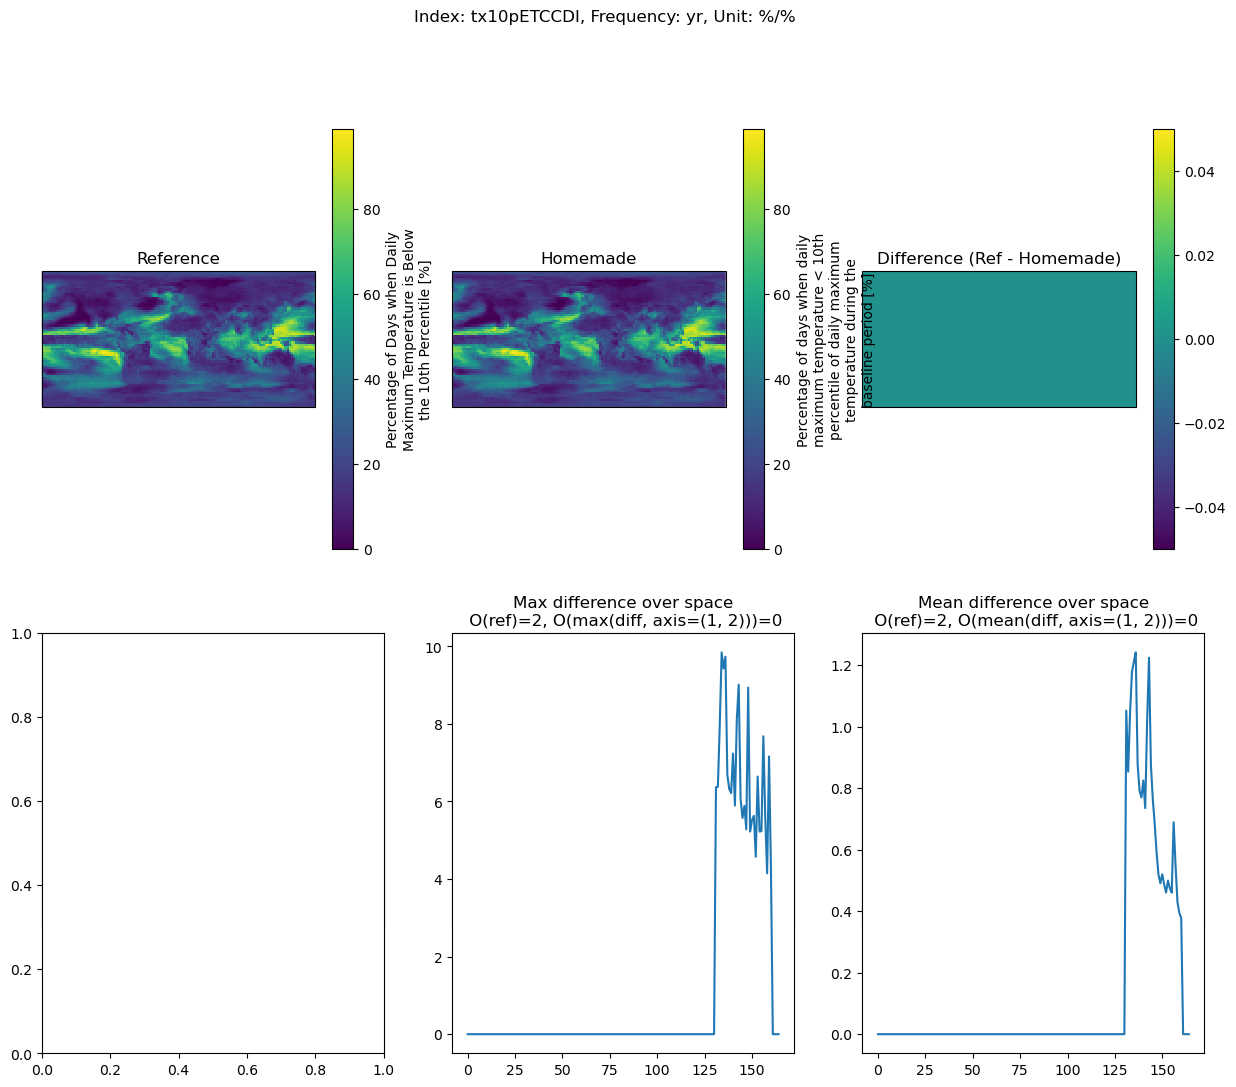


Skipping tx90pETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 1

Checking for tx90pETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


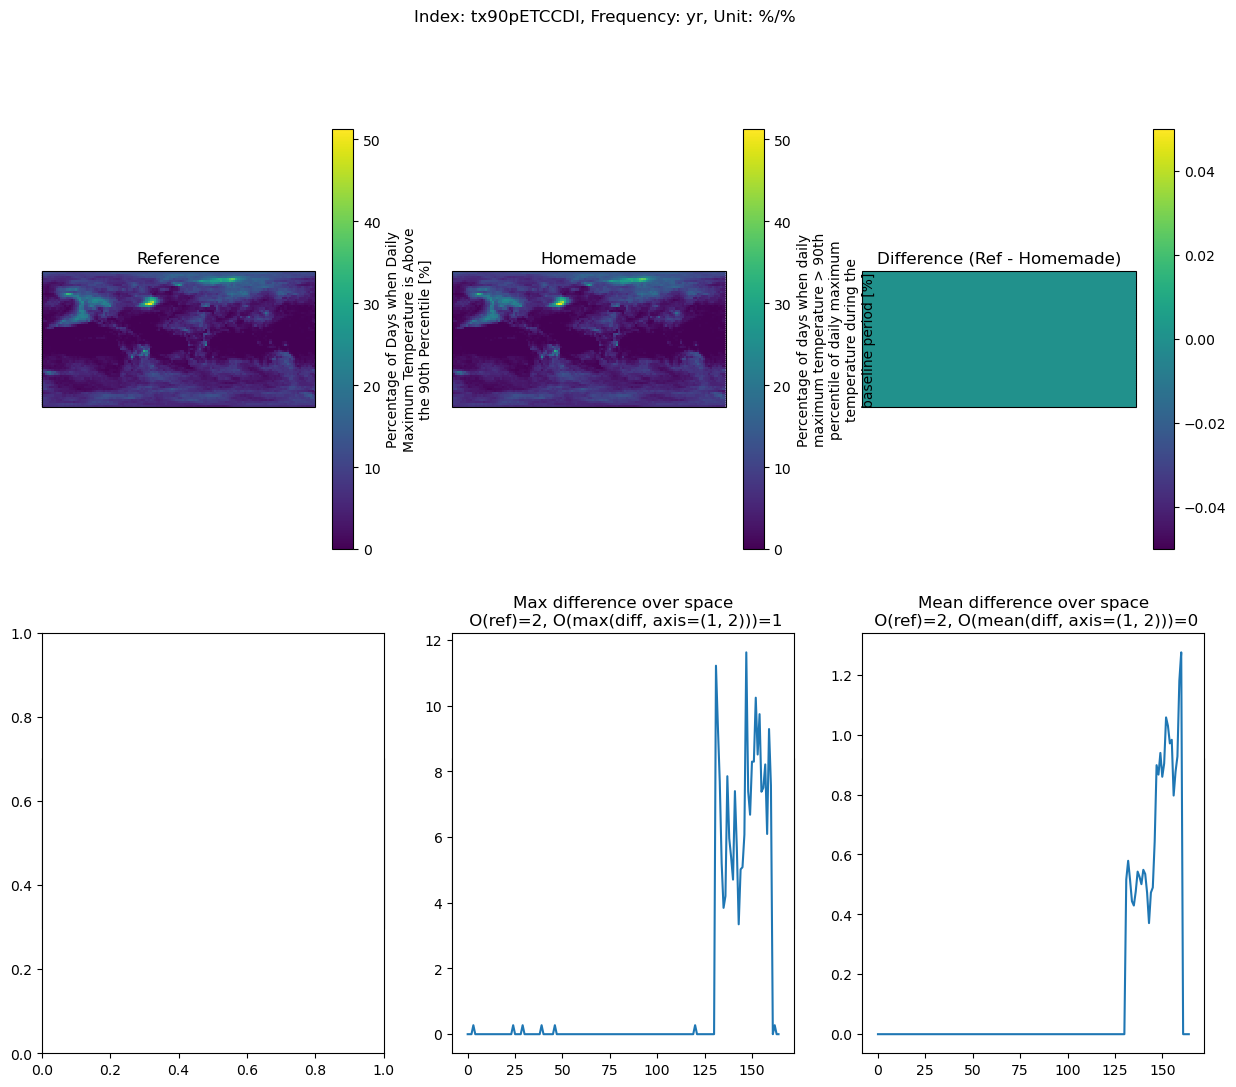


Skipping wsdiETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 0

Checking for wsdiETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/1666360429.py:60: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
/tmp/ipykernel_536296/1666360429.py:68: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


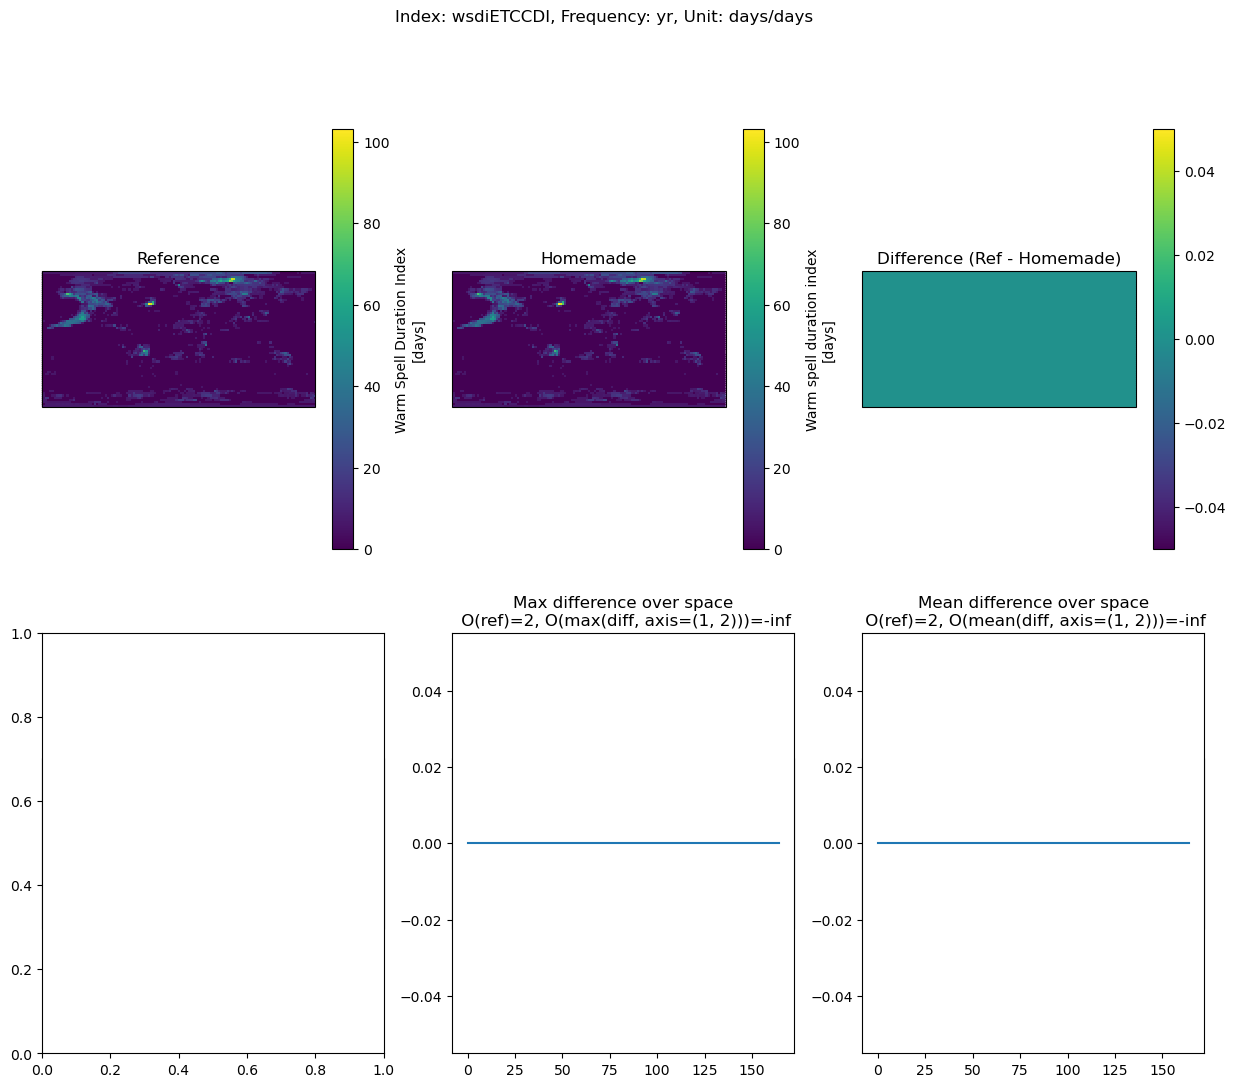


Skipping csdiETCCDI at mon due to unexpected number of files. Homemade: 0, ref: 0

Checking for csdiETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/1666360429.py:60: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
/tmp/ipykernel_536296/1666360429.py:68: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


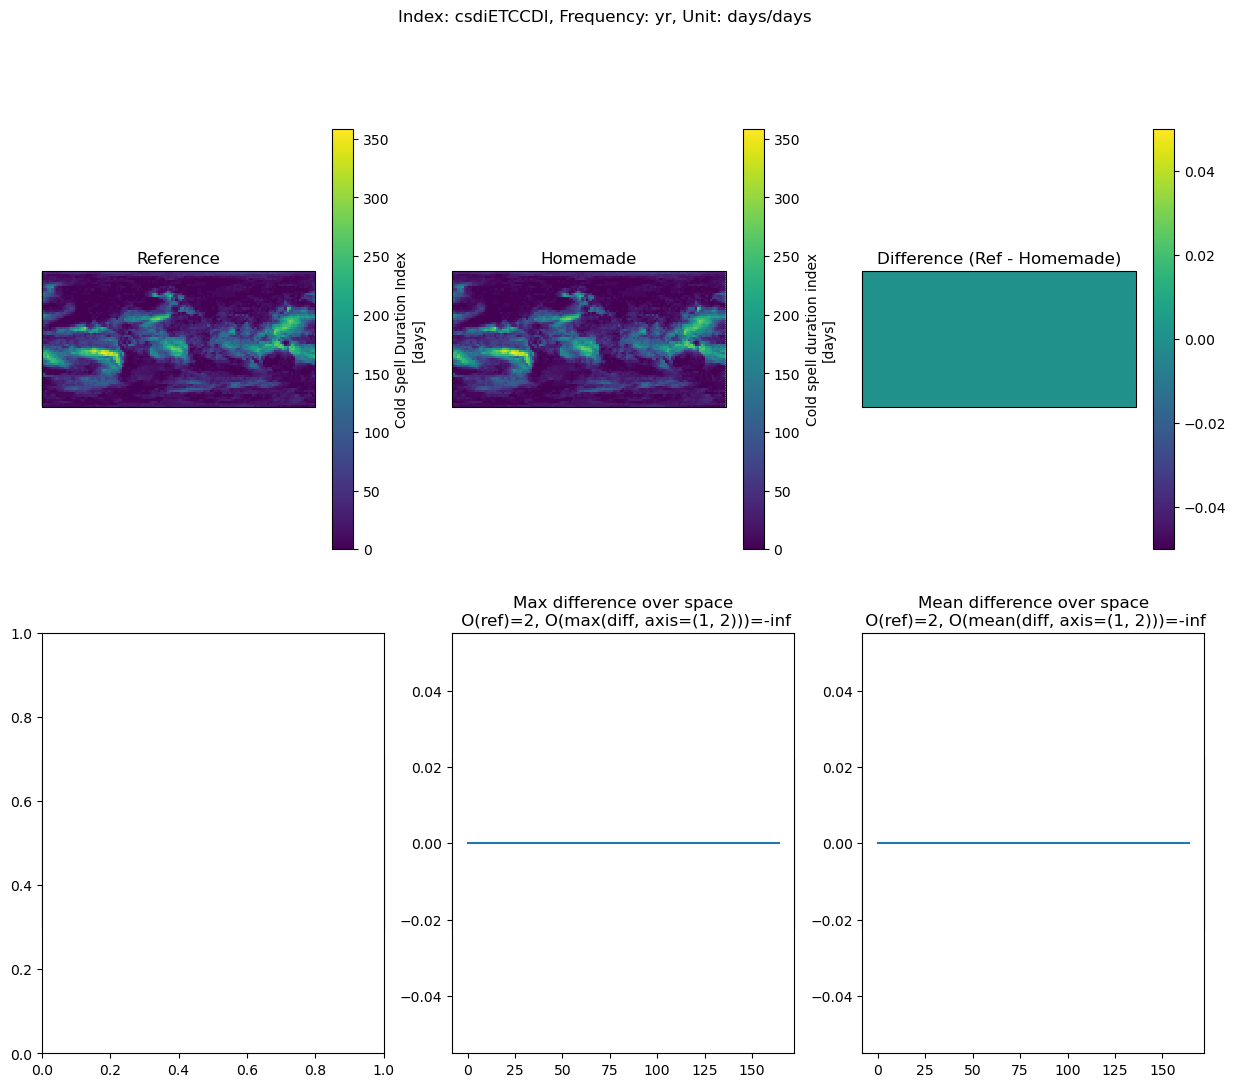

In [7]:
compute_fqs = ['mon', 'yr']
for index_id in index_ids:
    for compute_fq in compute_fqs:
        index_files_homemade =  [file for file in new_files if all(substring in file.name for substring in [index_id, compute_fq,'historical'])]
        index_files_ref = list(refdir_path.glob(f'{index_id}_{compute_fq}_*historical*.nc'))
        if len(index_files_homemade) != 1 or len(index_files_ref) != 1:
            print(f"Skipping {index_id} at {compute_fq} due to unexpected number of files. Homemade: {len(index_files_homemade)}, ref: {len(index_files_ref)}")
            print("")
            continue

        print(f'Checking for {index_id}')
        homemade_file = index_files_homemade[0]
        ref_file = index_files_ref[0]
        ref_ds = xr.open_dataset(ref_file, decode_timedelta=False)
        homemade_ds = xr.open_dataset(homemade_file, decode_timedelta=False)

        # --- check that the dimensions are equal
        print(" * Checking dimensions...")
        for dim in ref_ds.sizes:
            ref_dim = ref_ds.sizes[dim]
            homemade_dim = homemade_ds.sizes[dim]
            print(f"    * Reference dimension {dim}: {ref_dim}")
            print(f"    * Homemade dimension {dim}: {homemade_dim}")
            assert ref_ds.sizes[dim] == homemade_ds.sizes[dim], f"Dimension {dim} does not match: {ref_ds.sizes[dim]} != {homemade_ds.sizes[dim]}"

        # --- check that coordinates are equal
        print(" * Checking coordinates...")
        for coord in [coord for coord in ref_ds.coords if coord not in ['height']]:
            ref_coord = ref_ds[coord]
            homemade_coord = homemade_ds[coord]

            diff = ref_coord.values - homemade_coord.values
            if diff.dtype == 'float64':
                diff = np.abs(diff)
                assert (diff < 1e-5).all(), f"Coordinate {coord} does not match"
            else:
                import datetime
                assert all(val == datetime.timedelta(0) for val in diff), f"Coordinate {coord} does not match"
            print(f"    * Coordinate {coord} matches.")

        # --- plot
        fig, axs = plt.subplots(
            2, 3,
            figsize=(15, 12),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )
        # Replace bottom row with regular (non-projection) axes for line plots
        for j in range(3):
            axs[1, j] = fig.add_subplot(2, 3, 4 + j)
        homemade_ds[index_id].isel(time=0).plot(ax=axs[0,1])
        ref_ds[index_id].isel(time=0).plot(ax=axs[0,0])
        diff = ref_ds[index_id].values - homemade_ds[index_id].values
        diff_da = xr.DataArray(diff, coords=ref_ds[index_id].coords, dims=ref_ds[index_id].dims)
        diff_da.isel(time=0).plot(ax=axs[0,2])

        nanmean_diff = np.nanmean(diff, axis=(1, 2))
        axs[1, 2].plot(nanmean_diff)
        # find the difference in order of magnitude between diff and ref_ds[index_id]
        order_of_magnitude_ref = np.floor(np.log10(np.nanmax(np.abs(ref_ds[index_id].values))))
        order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
        magnitude_diff = order_of_magnitude_ref - order_of_magnitude_nanmeandiff
        axs[1, 2].set_title(f'Mean difference over space\n O(ref)={order_of_magnitude_ref:.0f}, O(mean(diff, axis=(1, 2)))={order_of_magnitude_nanmeandiff:.0f}')

        nanmax_diff = np.nanmax(diff, axis=(1, 2))
        axs[1, 1].plot(nanmax_diff)
        # find the difference in order of magnitude between diff and ref_ds[index_id]
        order_of_magnitude_ref = np.floor(np.log10(np.nanmax(np.abs(ref_ds[index_id].values))))
        order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))
        magnitude_diff = order_of_magnitude_ref - order_of_magnitude_nanmaxdiff
        axs[1, 1].set_title(f'Max difference over space\n O(ref)={order_of_magnitude_ref:.0f}, O(max(diff, axis=(1, 2)))={order_of_magnitude_nanmaxdiff:.0f}')

        fig.suptitle(f'Index: {index_id}, Frequency: {compute_fq}, Unit: {ref_ds[index_id].units}/{homemade_ds[index_id].units}')
        axs[0, 0].set_title('Reference')
        axs[0, 1].set_title('Homemade')
        axs[0, 2].set_title('Difference (Ref - Homemade)')
        plt.show()
        print("")

## Precipitation

In [11]:
index_ids = get_creatable_indices(subset="precipitation", print_msg=True).keys()

Available creatable precipitation indices:
 - cddETCCDI: Consecutive dry days,
 - cwdETCCDI: Consecutive wet days,
 - prcptotETCCDI: Annual total precipitation in wet days,
 - rnnmmETCCDI: Number of heavy precipitation days *,
 - r1mmETCCDI: Annual total wet-day precipitation,
 - r10mmETCCDI: Annual total heavy precipitation,
 - r20mmETCCDI: Annual total very heavy precipitation,
 - rxndayETCCDI: Maximum n-day precipitation *,
 - rx1dayETCCDI: Monthly maximum 1-day precipitation,
 - rx5dayETCCDI: Monthly maximum 5-day precipitation,
 - sdiiETCCDI: Simple daily intensity index,
 - r95pETCCDI: Annual total precipitation when daily precipitation exceeds the 95th percentile of wet-day precipitation,
 - r99pETCCDI: Annual total precipitation when daily precipitation exceeds the 99th percentile of wet-day precipitation,
 - r95pTOTETCCDI: Contribution of very wet days to total precipitation (%),
 - r99pTOTETCCDI: Contribution of extremely wet days to total precipitation (%),

* custom thresho

In [9]:
kwargs = {
    'threshold': {
        'rxndayETCCDI': 2,  # max 48 hour precip (n_days)
        'rnnmmETCCDI': 30,  # 30 mm precip
    },
    'spells_can_span_groups': {

        'cddETCCDI': True,
        'cwdETCCDI': True,
    }
}
new_files, skipped_files = compute_indices(
    indices="precipitation",
    compute_fq=['yr'],
    compute_backend='python',
    output_dir=savepath,
    output_file_template="cmip6",
    tasmax=None,
    tasmin=None,
    tas=None,
    pr=Path(raw_data_path / 'pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    overwrite=True,
    **kwargs
)

pyClimExtremes.indices.registry - DEBUG - Resolved indices to compute: [<class 'pyClimExtremes.indices.precipitation_indices.CDDINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.CWDINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.PRCPTOTINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.RnnmmINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.r1mmINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.r10mmINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.r20mmINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.RXndayINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.Rx1dayINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.Rx5dayINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.SDIIINDEX'>, <class 'pyClimExtremes.indices.precipitation_indices.R95pIndex'>, <class 'pyClimExtremes.indices.precipitation_indices.R99pIndex'>, <class 'pyClimExtremes.indices.precipitation_indices.R95pTOT

In [10]:
import nc_time_axis

Checking for cddETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/3506298009.py:74: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
/tmp/ipykernel_536296/3506298009.py:82: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


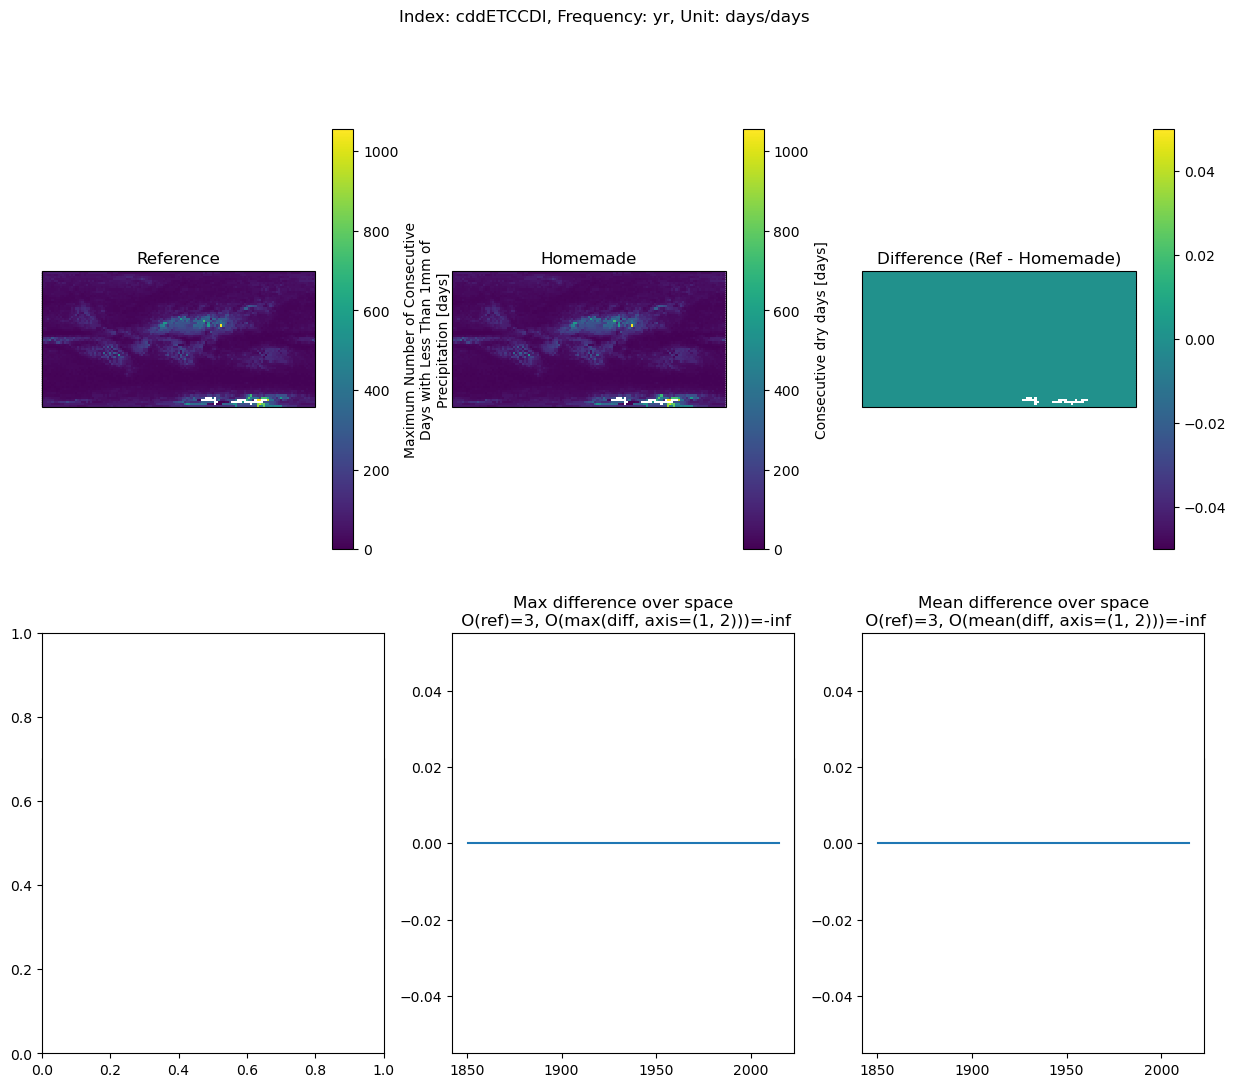


Checking for cwdETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/3506298009.py:74: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
/tmp/ipykernel_536296/3506298009.py:82: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


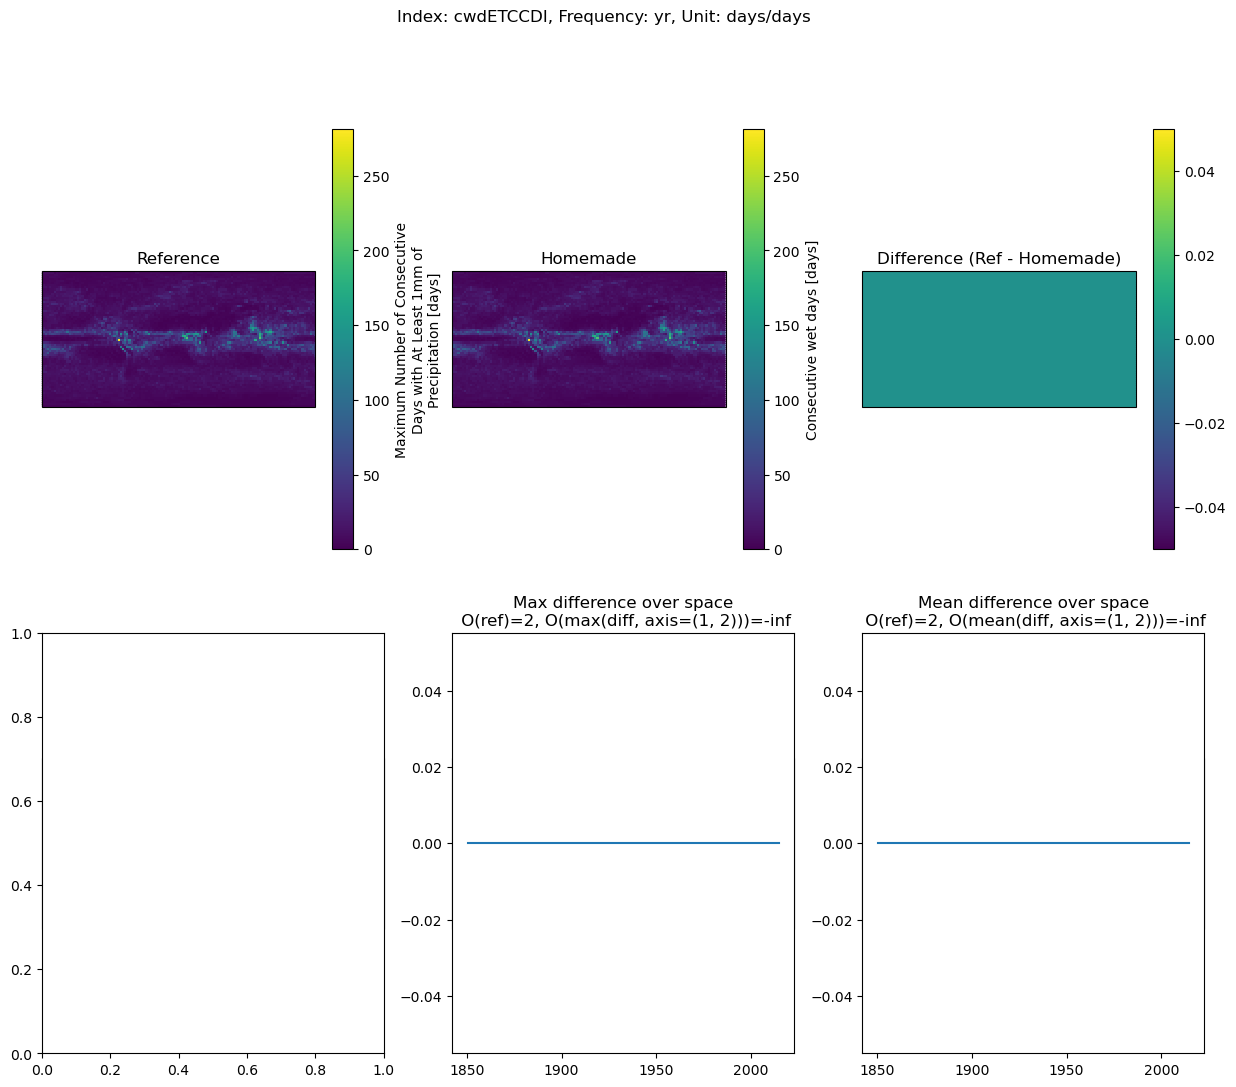


Checking for prcptotETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


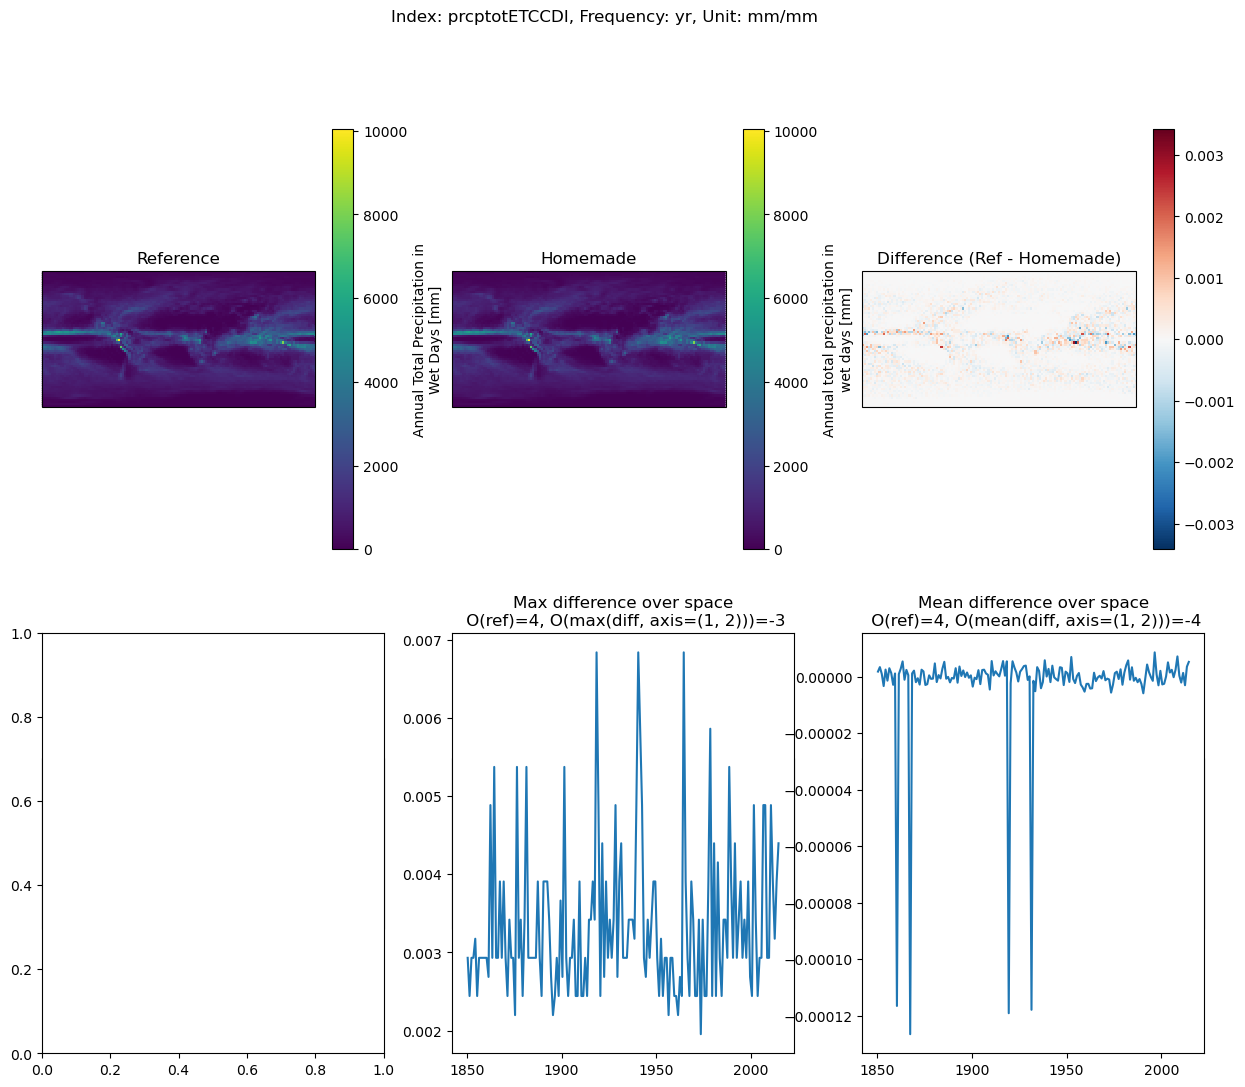


Skipping rnnmmETCCDI at yr due to unexpected number of files. Homemade: 1, ref: 0

Checking for r1mmETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/3506298009.py:82: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


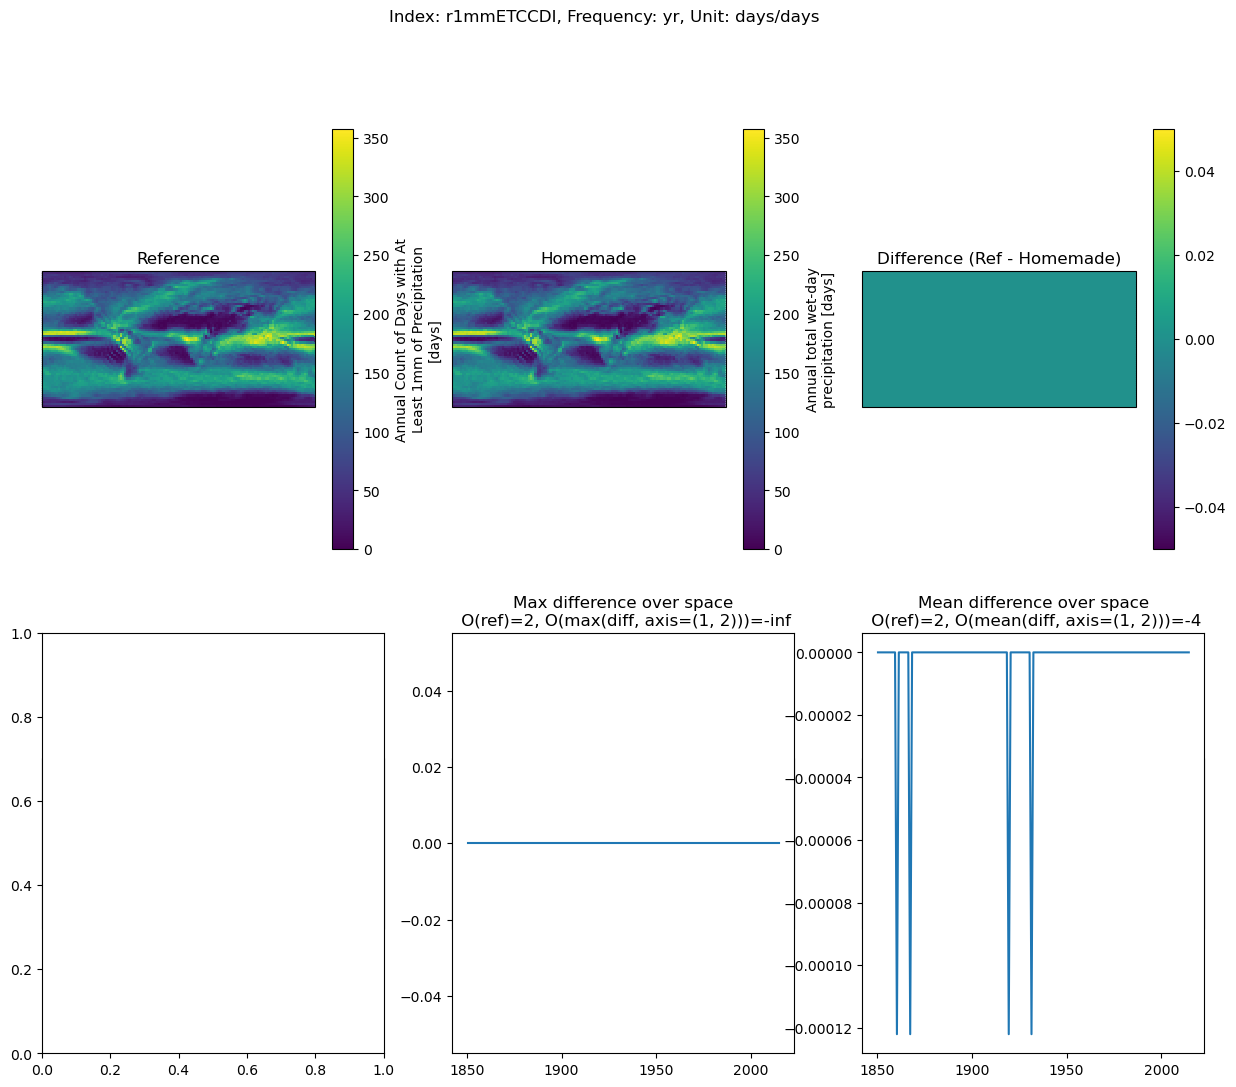


Checking for r10mmETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/3506298009.py:82: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


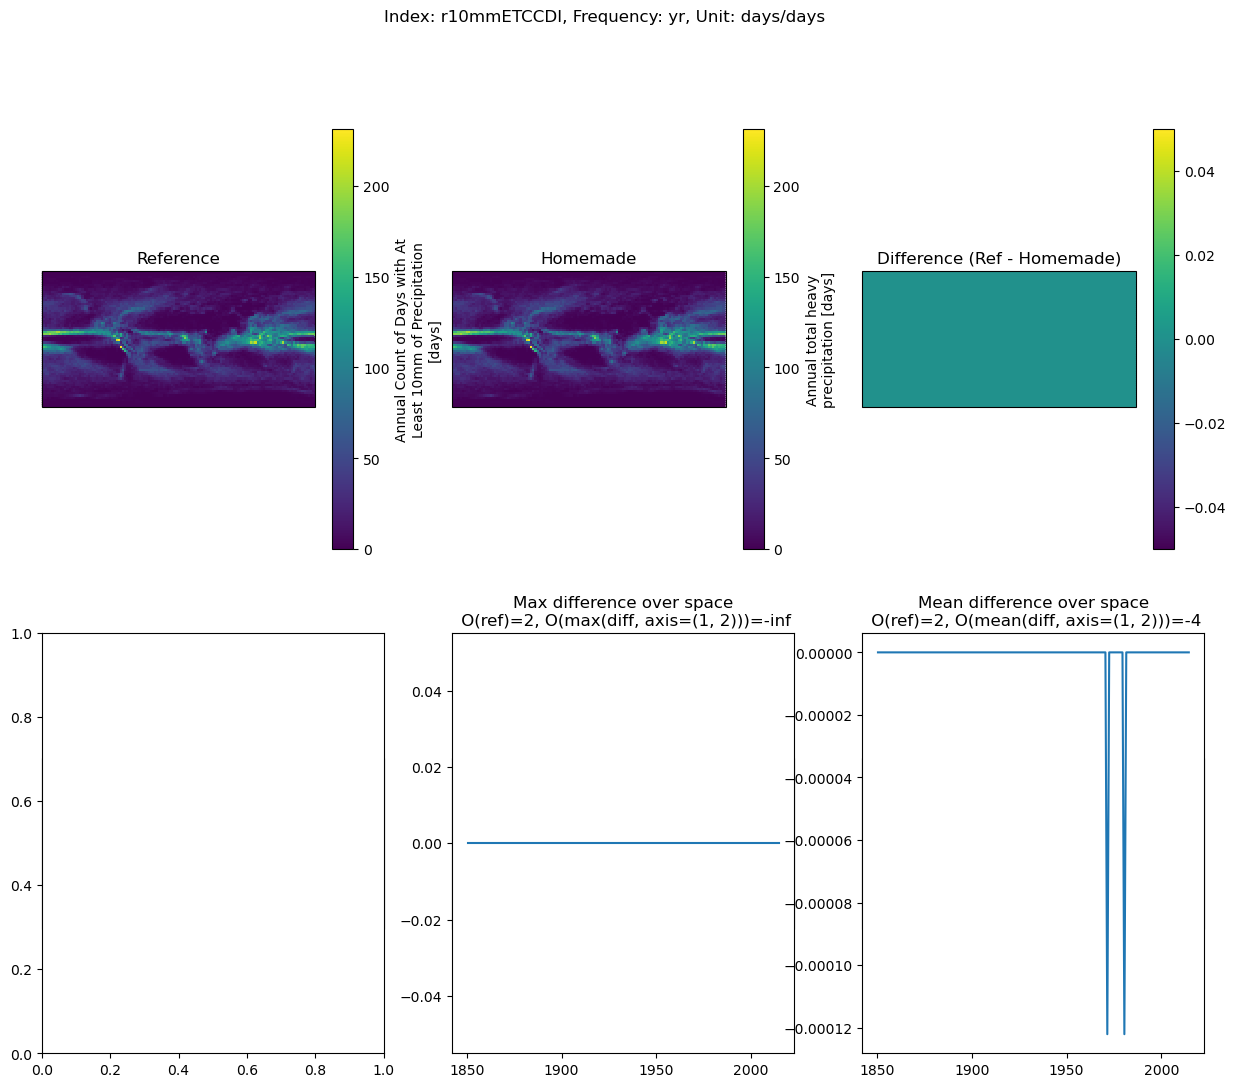


Checking for r20mmETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/3506298009.py:82: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


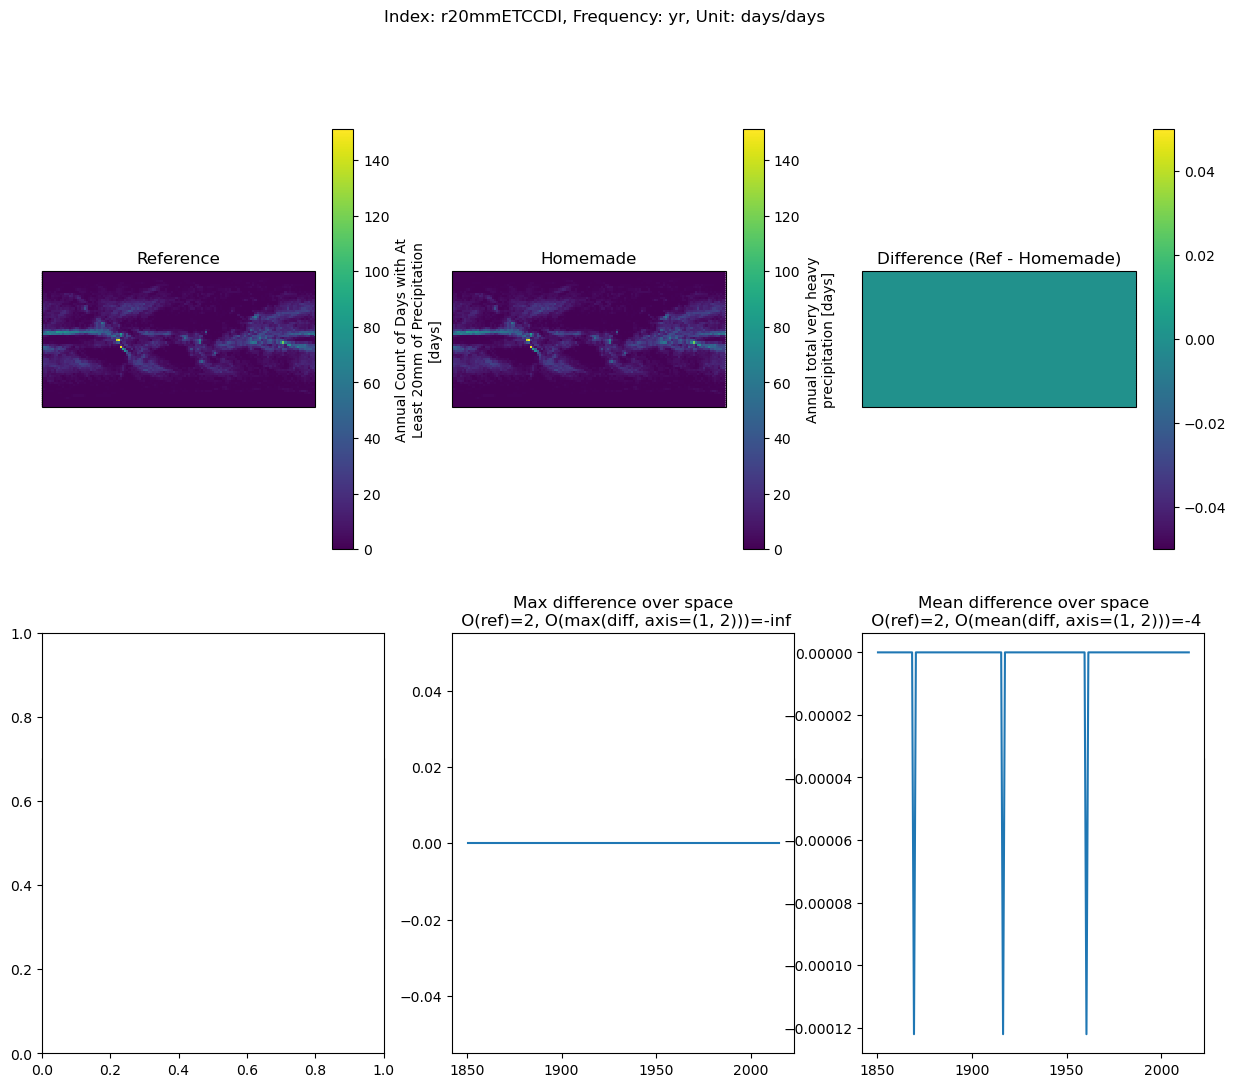


Skipping rxndayETCCDI at yr due to unexpected number of files. Homemade: 1, ref: 0

Checking for rx1dayETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


/tmp/ipykernel_536296/3506298009.py:74: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
/tmp/ipykernel_536296/3506298009.py:82: RuntimeWarning: divide by zero encountered in log10
  order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))


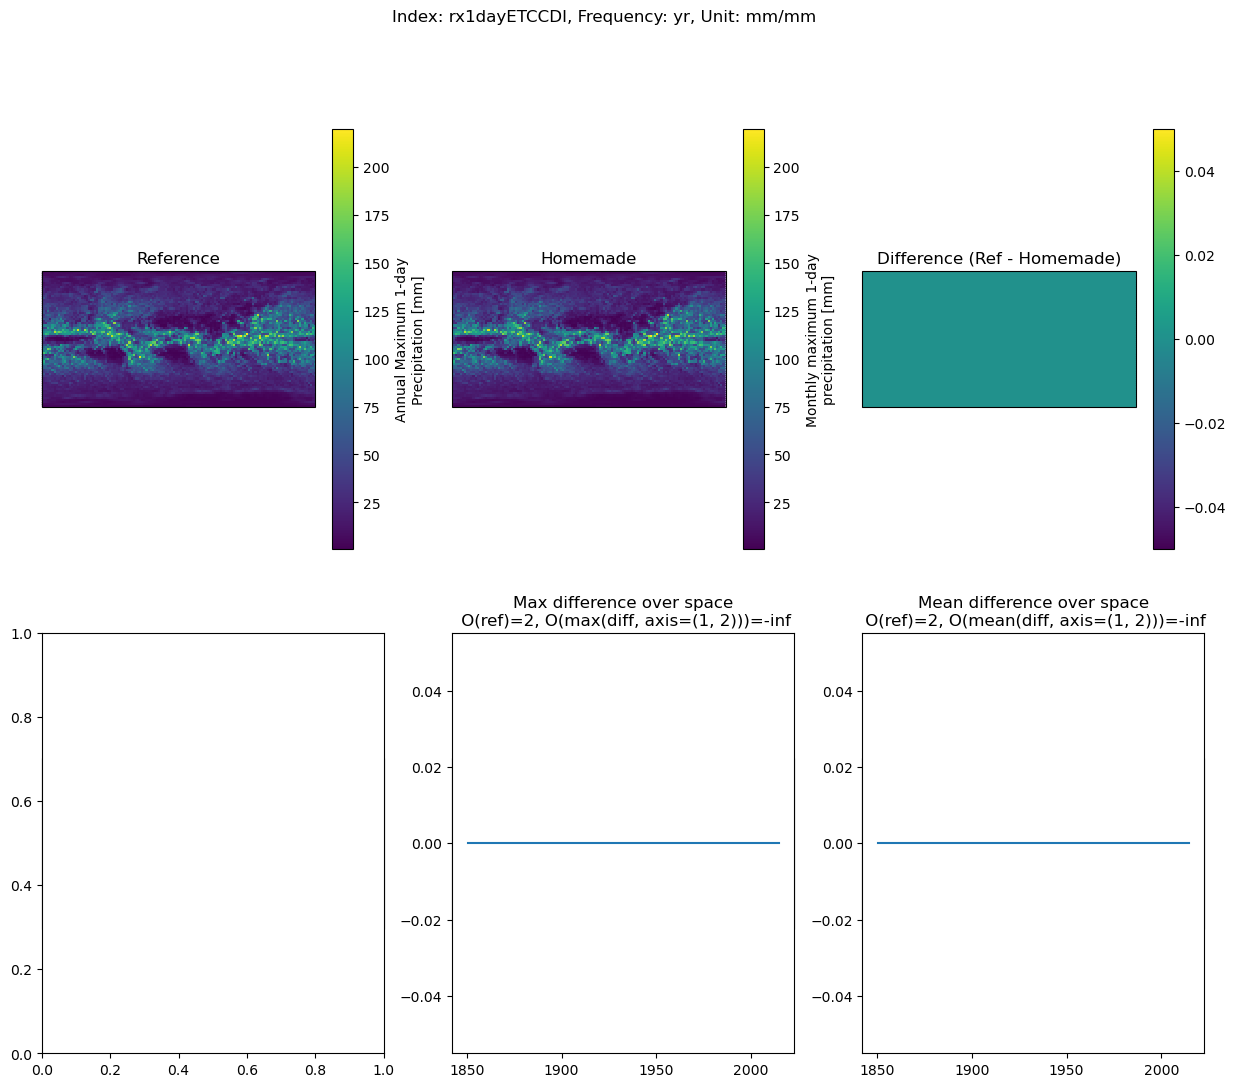


Checking for rx5dayETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


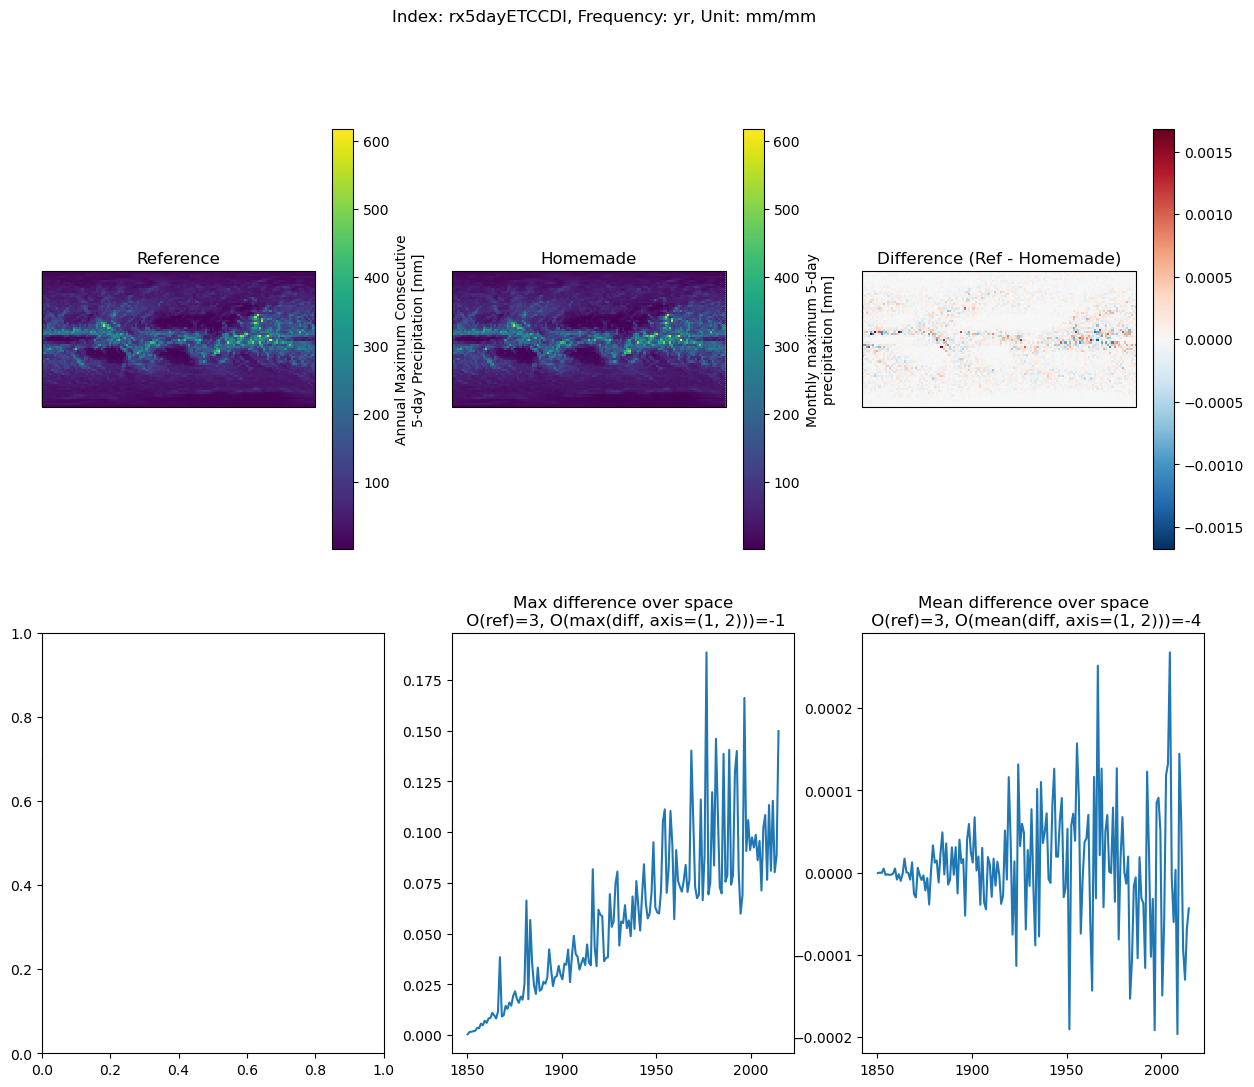


Checking for sdiiETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


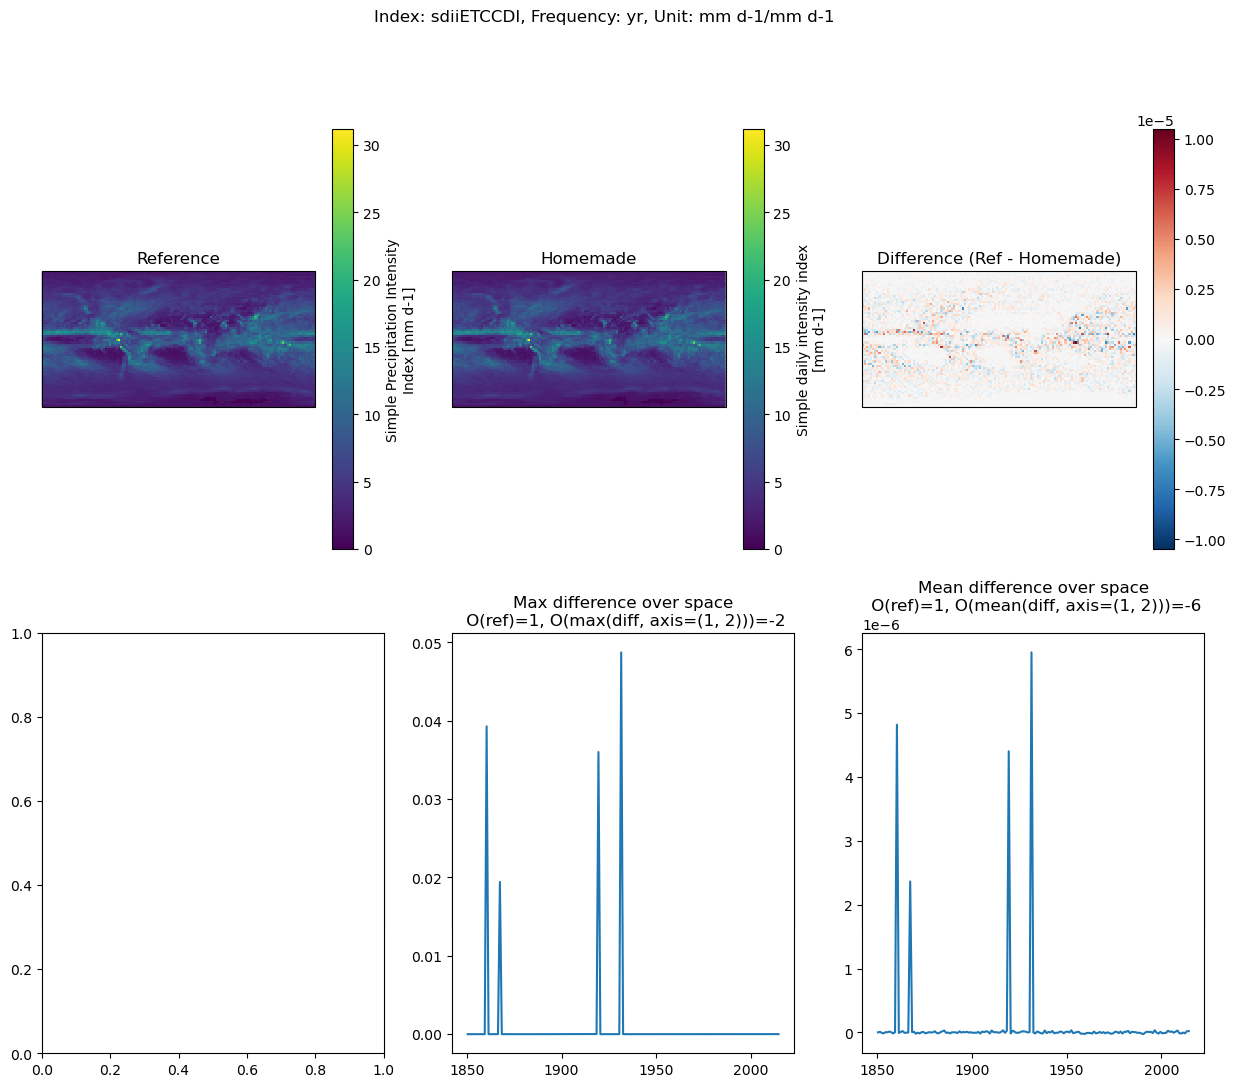


Checking for r95pETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


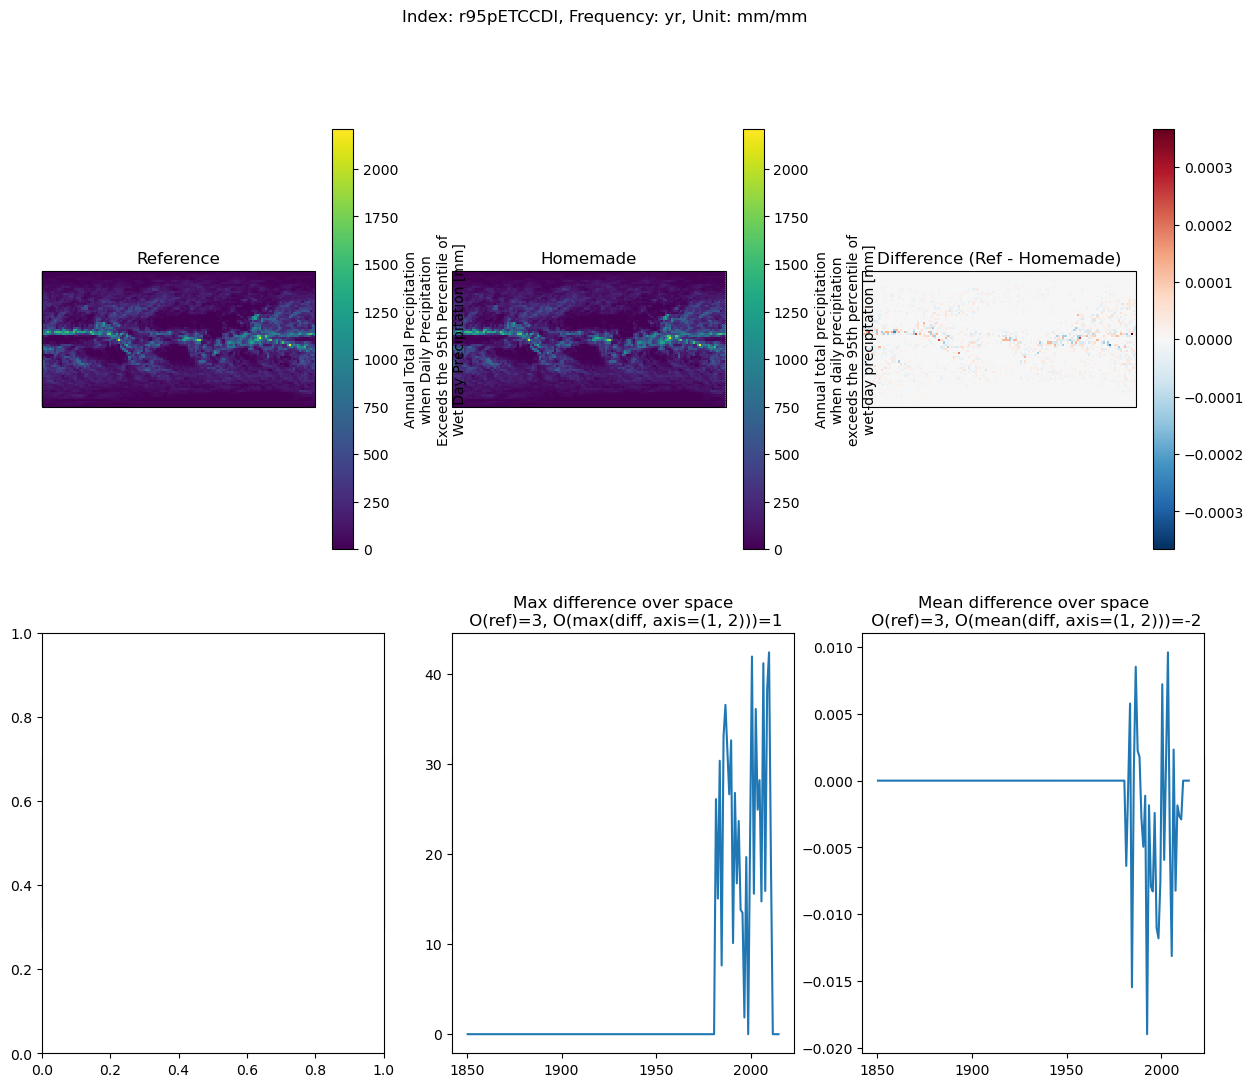


Checking for r99pETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


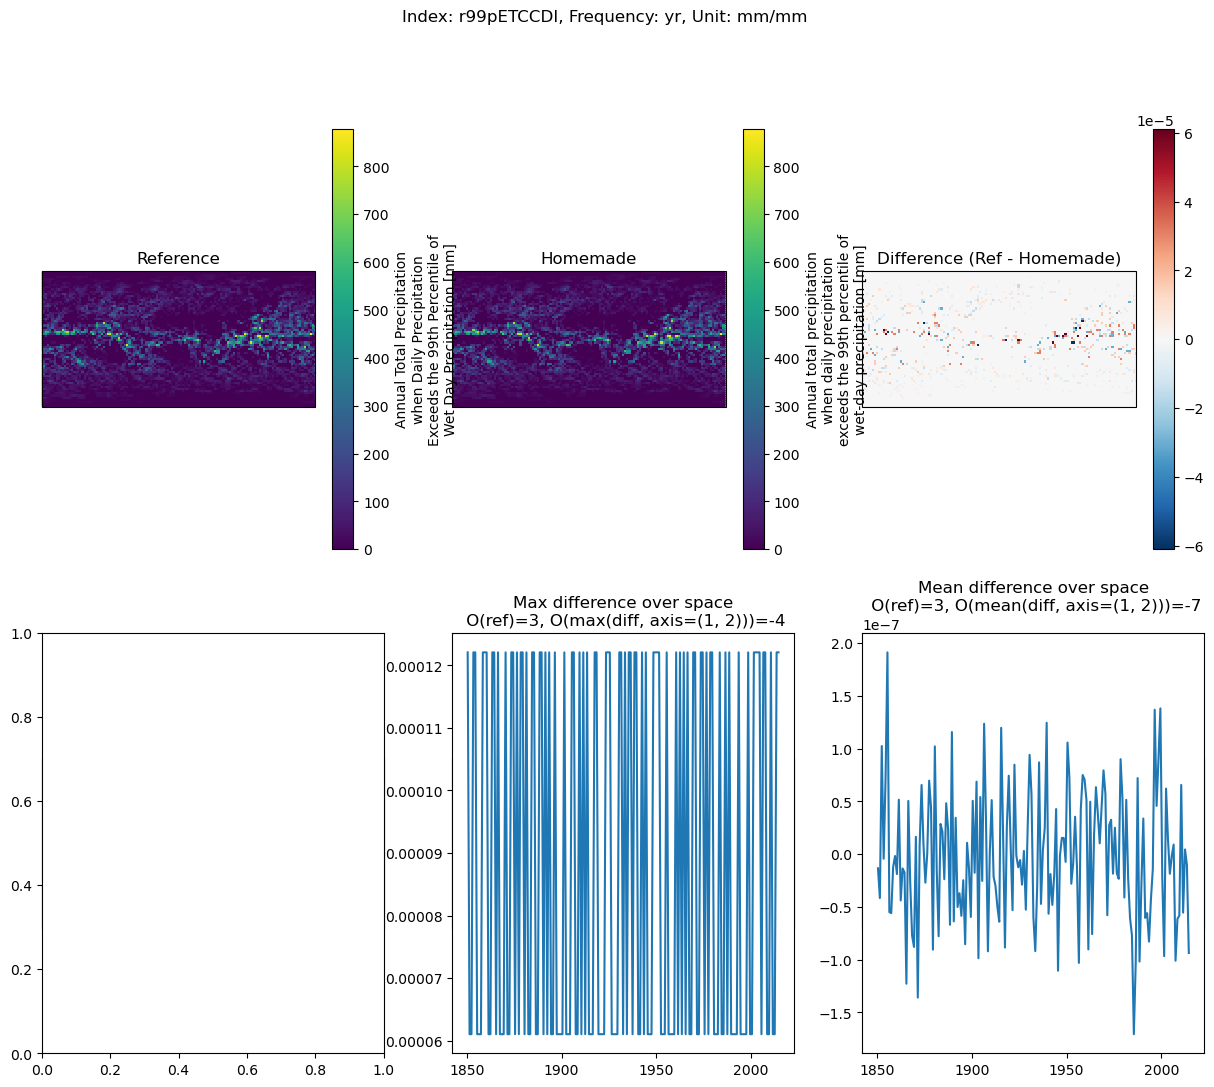


Skipping r95pTOTETCCDI at yr due to unexpected number of files. Homemade: 1, ref: 0

Skipping r99pTOTETCCDI at yr due to unexpected number of files. Homemade: 1, ref: 0



In [12]:
timestep_to_plot = 2

compute_fqs = ['yr']

for index_id in index_ids:
    for compute_fq in compute_fqs:
        no_ref = False
        index_files_homemade = [
            file for file in new_files
            if all(substring in file.name for substring in [index_id, compute_fq, 'historical'])
        ]
        index_files_ref = list(refdir_path.glob(f'{index_id}_{compute_fq}_*historical*.nc'))
        if len(index_files_ref) != 1:
            no_ref = True
            print(
                f"Skipping {index_id} at {compute_fq} due to unexpected number of files. "
                f"Homemade: {len(index_files_homemade)}, ref: {len(index_files_ref)}"
            )
            print("")
            continue

        print(f'Checking for {index_id}')
        homemade_file = index_files_homemade[0]
        ref_file = index_files_ref[0]
        ref_ds = xr.open_dataset(ref_file, decode_timedelta=False)
        homemade_ds = xr.open_dataset(homemade_file, decode_timedelta=False)
        time_array = ref_ds['time'].values

        # --- check that the dimensions are equal
        print(" * Checking dimensions...")
        for dim in ref_ds.sizes:
            ref_dim = ref_ds.sizes[dim]
            homemade_dim = homemade_ds.sizes[dim]
            print(f"    * Reference dimension {dim}: {ref_dim}")
            print(f"    * Homemade dimension {dim}: {homemade_dim}")
            assert ref_ds.sizes[dim] == homemade_ds.sizes[dim], f"Dimension {dim} does not match: {ref_ds.sizes[dim]} != {homemade_ds.sizes[dim]}"

        # --- check that coordinates are equal
        print(" * Checking coordinates...")
        for coord in [coord for coord in ref_ds.coords if coord not in ['height']]:
            ref_coord = ref_ds[coord]
            homemade_coord = homemade_ds[coord]

            diff = ref_coord.values - homemade_coord.values
            if diff.dtype == 'float64':
                diff = np.abs(diff)
                assert (diff < 1e-5).all(), f"Coordinate {coord} does not match"
            else:
                import datetime
                assert all(val == datetime.timedelta(0) for val in diff), f"Coordinate {coord} does not match"
            print(f"    * Coordinate {coord} matches.")

        # --- plot
        fig, axs = plt.subplots(
            2, 3,
            figsize=(15, 12),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )
        # Replace bottom row with regular (non-projection) axes for line plots
        for j in range(3):
            axs[1, j] = fig.add_subplot(2, 3, 4 + j)
        homemade_ds[index_id].isel(time=timestep_to_plot).plot(ax=axs[0,1])
        ref_ds[index_id].isel(time=timestep_to_plot).plot(ax=axs[0,0])
        diff = ref_ds[index_id].values - homemade_ds[index_id].values
        diff_da = xr.DataArray(diff, coords=ref_ds[index_id].coords, dims=ref_ds[index_id].dims)
        diff_da.isel(time=timestep_to_plot).plot(ax=axs[0,2])
        with open(index_id + '_' + compute_fq + '_diff.txt', 'w') as f:
            for row in diff_da.isel(time=timestep_to_plot).values:
                f.write(' '.join(f"{val:.2f}" for val in row) + '\n')
        nanmean_diff = np.nanmean(diff, axis=(1, 2))
        axs[1, 2].plot(time_array, nanmean_diff)
        # find the difference in order of magnitude between diff and ref_ds[index_id]
        order_of_magnitude_ref = np.floor(np.log10(np.nanmax(np.abs(ref_ds[index_id].values))))
        order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
        magnitude_diff = order_of_magnitude_ref - order_of_magnitude_nanmeandiff
        axs[1, 2].set_title(f'Mean difference over space\n O(ref)={order_of_magnitude_ref:.0f}, O(mean(diff, axis=(1, 2)))={order_of_magnitude_nanmeandiff:.0f}')

        nanmax_diff = np.nanmax(diff, axis=(1, 2))
        axs[1, 1].plot(time_array, nanmax_diff)
        # find the difference in order of magnitude between diff and ref_ds[index_id]
        order_of_magnitude_ref = np.floor(np.log10(np.nanmax(np.abs(ref_ds[index_id].values))))
        order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))
        magnitude_diff = order_of_magnitude_ref - order_of_magnitude_nanmaxdiff
        axs[1, 1].set_title(f'Max difference over space\n O(ref)={order_of_magnitude_ref:.0f}, O(max(diff, axis=(1, 2)))={order_of_magnitude_nanmaxdiff:.0f}')

        fig.suptitle(f'Index: {index_id}, Frequency: {compute_fq}, Unit: {ref_ds[index_id].units}/{homemade_ds[index_id].units}')
        axs[0, 0].set_title('Reference')
        axs[0, 1].set_title('Homemade')
        axs[0, 2].set_title('Difference (Ref - Homemade)')
        plt.show()
        print("")